## ComplyPilot JB - Final LangGraph State & Node Flow

### 0. 미션

이번 LangGraph 설계의 목표는 금융 대고객 콘텐츠를 업로드하면 AI Agent가 준법 리스크를 1차 검토하고, 근거 검색·수정안 생성·Guardrail 검증·조건부 Routing까지 수행하는 최종 Workflow를 검증하는 것이다.

ComplyPilot JB는 단순한 문구 탐지기가 아니라, 하나의 Agent State를 공유하는 여러 노드가 순차적으로 상태를 업데이트하고, 리스크 등급과 Guardrail 결과에 따라 다음 실행 경로를 선택하는 Routing + Reflection Hybrid Graph 구조를 가진다.

최종 목표 흐름은 다음과 같다.

input text/file
→ file intake
→ extract text
→ detect product/channel/language
→ user confirmation
→ map review criteria
→ detect risks
→ check missing disclaimers
→ retrieve evidence
→ judge risk
→ generate rewrite
→ check guardrail
→ route next action
→ report / retrieve retry / rewrite retry / HITL
→ save result
→ end

본 그래프의 핵심 목적은 다음과 같다.

금융 광고·마케팅 콘텐츠의 위험 표현과 필수 고지 누락 가능성을 탐지한다.
공개 금융규제 문서와 광고 가이드라인에서 관련 근거를 검색한다.
리스크 등급을 High / Medium / Low / Pass로 산정한다.
위험 문구에 대한 수정안과 필수 고지 문구를 생성한다.
AI가 생성한 수정안과 판단 결과를 Guardrail Checker로 재검증한다.
근거 부족 또는 수정안 오류가 발생하면 재검색 또는 재작성 루프로 되돌린다.
고위험, 근거 부족, 재시도 초과, OCR 불확실 건은 준법관리자 검토 대상으로 전환한다.

### 1. 최종 LangGraph 구조

ComplyPilot JB의 최종 그래프는 다음과 같은 노드로 구성된다.<br>

__start__<br>
→ file_intake<br>
→ text_extractor<br>
→ content_auto_detector<br>
→ user_confirmation<br>
→ review_criteria_mapper<br>
→ risk_detector<br>
→ disclaimer_checker<br>
→ evidence_retriever<br>
→ risk_judge<br>
→ rewrite_generator<br>
→ guardrail_checker<br>
→ routing<br>

routing 노드 이후에는 조건에 따라 다음 경로로 분기한다.<br>

routing
├─ report   → report_output → save_result → __end__<br>
├─ hitl     → hitl_review → save_result → __end__<br>
├─ retrieve → evidence_retriever 재검색 루프<br>
└─ rewrite  → rewrite_generator 재작성 루프<br>

이 구조는 단순 순차 그래프가 아니라, 리스크 등급과 Guardrail 상태에 따라 실행 경로가 달라지는 Routing Graph이며, 동시에 근거 부족·수정안 오류 발생 시 재검색/재작성 루프를 수행하는 Reflection 구조를 포함한다.

### 2. 환경 준비
2-1. 라이브러리 로딩<br>
목적: LangGraph Workflow 구현에 필요한 기본 라이브러리 로딩<br>
입력: 없음<br>
출력: Python 실행 환경<br>
처리:<br>
typing, pathlib, json, re, pandas 로딩<br>
LangGraph의 StateGraph, START, END 로딩<br>
필요 시 PDF, DOCX, OCR, RAG 관련 라이브러리 로딩<br>
2-2. 프로젝트 경로 설정<br>
목적: 노트북에서 프로젝트 내부 모듈과 데이터 파일을 안정적으로 불러오기<br>
입력: 현재 노트북 경로<br>
출력: PROJECT_ROOT<br>
처리:<br>
프로젝트 루트 경로 설정<br>
core/, graph/, data/ 경로 import 가능하게 구성<br>
JSON 룰 파일과 규정 문서 경로 확인

In [152]:
# ============================================================
# 2-1. 라이브러리 로딩
# 목적:
# - LangGraph Workflow 구현에 필요한 기본 라이브러리 로딩
# - PDF, DOCX, OCR, RAG, Vector DB 관련 라이브러리 로딩
# ============================================================

from __future__ import annotations

import os
import re
import sys
import json
from pathlib import Path
from typing import Any, TypedDict, Literal

import pandas as pd

from dotenv import load_dotenv

from langgraph.graph import StateGraph, START, END

# RAG / Vector DB 관련 라이브러리
from langchain_community.document_loaders import DirectoryLoader, PyMuPDFLoader
from langchain_text_splitters import CharacterTextSplitter, RecursiveCharacterTextSplitter
from langchain_openai import OpenAIEmbeddings, ChatOpenAI
from langchain_chroma import Chroma

# Legacy Chain / Memory 사용 시
from langchain_classic.chains import ConversationalRetrievalChain
from langchain_classic.memory import ConversationBufferMemory

In [153]:
# ============================================================
# 2-2. 프로젝트 경로 설정
# 목적:
# - 노트북에서 core/, graph/, data/ 모듈을 안정적으로 불러오기
# - JSON 룰 파일, 샘플 데이터, 규정 문서 경로를 고정
# ============================================================

def find_project_root(start_path: Path | None = None) -> Path:
    """
    현재 위치에서 상위 폴더로 올라가며 프로젝트 루트를 찾는다.

    프로젝트 루트 판단 기준:
    - README.md 또는 AGENTS.md가 있고
    - data/ 폴더가 존재하는 위치
    """
    current_path = (start_path or Path.cwd()).resolve()

    for path in [current_path, *current_path.parents]:
        has_marker = (path / "README.md").exists() or (path / "AGENTS.md").exists()
        has_data_dir = (path / "data").exists()

        if has_marker and has_data_dir:
            return path

    # 못 찾으면 현재 작업 디렉터리를 프로젝트 루트로 사용
    return current_path


PROJECT_ROOT = find_project_root()

# Python import 경로에 프로젝트 루트 추가
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

DATA_DIR = PROJECT_ROOT / "data"
RULES_DIR = DATA_DIR / "rules"
REGULATIONS_DIR = DATA_DIR / "regulations"
SAMPLES_DIR = DATA_DIR / "samples"
OUTPUTS_DIR = PROJECT_ROOT / "outputs"
REPORTS_DIR = OUTPUTS_DIR / "reports"
VECTOR_DB_DIR = PROJECT_ROOT / "vector_db"

# 필요한 폴더가 없으면 생성
for directory in [DATA_DIR, RULES_DIR, REGULATIONS_DIR, SAMPLES_DIR, OUTPUTS_DIR, REPORTS_DIR, VECTOR_DB_DIR]:
    directory.mkdir(parents=True, exist_ok=True)

print(f"✅ PROJECT_ROOT: {PROJECT_ROOT}")
print(f"✅ DATA_DIR: {DATA_DIR}")
print(f"✅ RULES_DIR: {RULES_DIR}")
print(f"✅ REGULATIONS_DIR: {REGULATIONS_DIR}")
print(f"✅ SAMPLES_DIR: {SAMPLES_DIR}")
print(f"✅ VECTOR_DB_DIR: {VECTOR_DB_DIR}")

✅ PROJECT_ROOT: C:\Users\USER\Desktop\complypilot-jb
✅ DATA_DIR: C:\Users\USER\Desktop\complypilot-jb\data
✅ RULES_DIR: C:\Users\USER\Desktop\complypilot-jb\data\rules
✅ REGULATIONS_DIR: C:\Users\USER\Desktop\complypilot-jb\data\regulations
✅ SAMPLES_DIR: C:\Users\USER\Desktop\complypilot-jb\data\samples
✅ VECTOR_DB_DIR: C:\Users\USER\Desktop\complypilot-jb\vector_db


In [154]:
# ============================================================
# 2-3. 환경변수 로딩
# 목적:
# - OPENAI_API_KEY 등 민감한 값을 .env에서 로드
# - API Key가 없어도 룰 기반 / BM25 fallback은 동작 가능하게 구성
# ============================================================

ENV_PATH = PROJECT_ROOT / ".env"

if ENV_PATH.exists():
    load_dotenv(ENV_PATH, override=True)
    print("✅ .env 파일 로딩 완료")
else:
    print("⚠️ .env 파일이 없습니다. OpenAI 기반 기능은 비활성화될 수 있습니다.")

OPENAI_API_KEY = os.getenv("OPENAI_API_KEY")

if OPENAI_API_KEY:
    print("✅ OPENAI_API_KEY 확인 완료")
else:
    print("⚠️ OPENAI_API_KEY 없음: OpenAI Embedding/LLM 기능은 fallback으로 처리하세요.")

✅ .env 파일 로딩 완료
✅ OPENAI_API_KEY 확인 완료


In [155]:
# ============================================================
# 2-4. 주요 파일 경로 확인
# 목적:
# - 룰 JSON, 규정 문서, 샘플 입력 데이터가 있는지 확인
# ============================================================

rule_files = {
    "product_keywords": RULES_DIR / "product_keywords.json",
    "risk_rules": RULES_DIR / "risk_rules.json",
    "disclaimer_rules": RULES_DIR / "disclaimer_rules.json",
    "rewrite_templates": RULES_DIR / "rewrite_templates.json",
}

for name, path in rule_files.items():
    status = "✅ 존재" if path.exists() else "⚠️ 없음"
    print(f"{name}: {status} - {path}")

print("\n📄 regulations files:")
for file_path in REGULATIONS_DIR.glob("*"):
    print("-", file_path.name)

print("\n📁 sample files:")
for file_path in SAMPLES_DIR.rglob("*"):
    if file_path.is_file():
        print("-", file_path.relative_to(SAMPLES_DIR))

product_keywords: ✅ 존재 - C:\Users\USER\Desktop\complypilot-jb\data\rules\product_keywords.json
risk_rules: ✅ 존재 - C:\Users\USER\Desktop\complypilot-jb\data\rules\risk_rules.json
disclaimer_rules: ✅ 존재 - C:\Users\USER\Desktop\complypilot-jb\data\rules\disclaimer_rules.json
rewrite_templates: ✅ 존재 - C:\Users\USER\Desktop\complypilot-jb\data\rules\rewrite_templates.json

📄 regulations files:
- fair_advertising_law.txt
- financial_ad_guideline.txt
- financial_consumer_protection.txt

📁 sample files:
- K패스+신용카드_상품설명서.pdf
- sample_high_risk.txt
- sample_missing_disclaimer.txt
- sample_normal.txt
- temp_agent_smoke.txt
- 가계대출 상품설명서.pdf
- 가계대출_상품설명서.pdf
- 부동산 담보대출 약관_개정_20260226시행.pdf
- 주택담보대출_상품설명서.pdf


### 3. Agent State Schema

각 노드는 하나의 ComplianceState를 공유한다.
이전 노드의 처리 결과는 State에 저장되고, 다음 노드는 해당 State를 이어받아 자신이 담당하는 필드만 업데이트한다.

목적: 전체 Agent Workflow에서 공유되는 상태값 정의
입력: 없음
출력: ComplianceState
처리:
파일 정보, 추출 텍스트, 상품/채널/언어 탐지 결과 저장
사용자 확인값과 검토 기준 저장
위험 표현, 누락 고지, RAG 근거, 리스크 등급 저장
수정안, Guardrail 결과, Routing 결과, 최종 Report 저장
재검색·재작성 반복 횟수와 HITL 필요 여부 저장

주요 State 항목은 다음과 같다.

File/Input:
- uploaded_file
- file_name
- file_type

Extraction:
- raw_text
- ocr_text
- extracted_text
- extraction_confidence

Detection:
- detected_product_type
- detected_channel
- detected_language
- confirmed_product_type
- confirmed_channel
- confirmed_language

Review:
- review_criteria
- optional_conditions
- sentences
- detected_risks
- missing_disclaimers

Evidence/Judgment:
- evidence_list
- evidence_score
- risk_level
- risk_reason
- review_required

Output/Control:
- rewrite_text
- required_disclaimer
- guardrail_status
- retry_count
- max_retry
- next_action
- report

In [156]:
# ============================================================
# 3. Agent State Schema
# 목적:
# - 전체 Agent Workflow에서 공유되는 상태값 정의
# - POC 단계에서는 노트북 안에서 먼저 검증하고, 이후 core/state.py로 정리
# ============================================================

from typing import Any, TypedDict


class ComplianceState(TypedDict, total=False):
    # File/Input
    uploaded_file: Any
    file_path: str
    file_name: str
    file_type: str
    file_size: int

    # Extraction
    raw_text: str
    ocr_text: str
    extracted_text: str
    extraction_confidence: float
    extraction_method: str
    extraction_quality: dict[str, Any]

    # Detection
    detected_product_type: str
    detected_product_label: str
    detected_channel: str
    detected_language: str
    detection_detail: dict[str, Any]

    # User Confirmation
    user_product_type: str
    user_channel: str
    user_language: str
    confirmed_product_type: str
    confirmed_product_label: str
    confirmed_channel: str
    confirmed_channel_label: str
    confirmed_language: str
    confirmed_language_label: str
    confirmation_detail: dict[str, Any]

    # Review Criteria
    review_criteria: dict[str, Any]
    optional_conditions: dict[str, Any]

    # Risk Detection
    sentences: list[str]
    detected_risks: list[dict[str, Any]]
    risk_detection_summary: dict[str, Any]

    # Disclaimer Check
    disclaimer_results: list[dict[str, Any]]
    missing_disclaimers: list[dict[str, Any]]
    disclaimer_check_summary: dict[str, Any]

    # Evidence Retrieval
    evidence_queries: list[dict[str, Any]]
    evidence_list: list[dict[str, Any]]
    evidence_score: float
    evidence_summary: dict[str, Any]

    # Judgment
    risk_level: str
    risk_reason: str
    review_required: bool
    judgment_detail: dict[str, Any]

    # Rewrite
    rewrite_text: str
    required_disclaimer: str
    rewrite_detail: dict[str, Any]

    # Guardrail
    guardrail_status: str
    needs_hitl: bool
    needs_rewrite: bool
    needs_retrieval_retry: bool
    guardrail_detail: dict[str, Any]

    # Routing
    retry_count: int
    max_retry: int
    next_action: str
    routing_detail: dict[str, Any]

    # Report
    report: dict[str, Any]
    report_tables: dict[str, list[dict[str, Any]]]

    # HITL
    review_status: str
    hitl_detail: dict[str, Any]

    # Save Result
    saved_result: dict[str, Any]

    # End
    workflow_status: str
    final_message: str
    completed_at: str
    is_done: bool
    final_result: dict[str, Any]

In [94]:
print("ComplianceState fields:")
for field_name in ComplianceState.__annotations__:
    print("-", field_name)

ComplianceState fields:
- uploaded_file
- file_path
- file_name
- file_type
- file_size
- raw_text
- ocr_text
- extracted_text
- extraction_confidence
- extraction_method
- extraction_quality
- detected_product_type
- detected_product_label
- detected_channel
- detected_language
- detection_detail
- user_product_type
- user_channel
- user_language
- confirmed_product_type
- confirmed_product_label
- confirmed_channel
- confirmed_channel_label
- confirmed_language
- confirmed_language_label
- confirmation_detail
- review_criteria
- optional_conditions
- sentences
- detected_risks
- risk_detection_summary
- disclaimer_results
- missing_disclaimers
- disclaimer_check_summary
- evidence_queries
- evidence_list
- evidence_score
- evidence_summary
- risk_level
- risk_reason
- review_required
- judgment_detail
- rewrite_text
- required_disclaimer
- rewrite_detail
- guardrail_status
- needs_hitl
- needs_rewrite
- needs_retrieval_retry
- guardrail_detail
- retry_count
- max_retry
- next_action


### 4. Node 1 - File Intake
목적: 업로드된 파일을 수집하고 파일 형식을 판별 <br>
입력: uploaded_file<br>
출력: file_name, file_type<br>
처리:<br>
파일명 추출<br>
확장자 또는 MIME type 확인<br>
PDF / DOCX / Image 지원 여부 검증<br>
지원하지 않는 형식이면 오류 상태 반환<br>
구현 방향: 룰 기반<br>
AI 사용 여부: 사용하지 않음

In [157]:
# ============================================================
# 4. Node 1 - File Intake
# ============================================================

from pathlib import Path

SUPPORTED_FILE_TYPES = {
    ".pdf": "pdf",
    ".docx": "docx",
    ".txt": "txt",
    ".png": "image",
    ".jpg": "image",
    ".jpeg": "image",
}


def resolve_project_path(path_value: str | Path | None) -> Path | None:
    if not path_value:
        return None

    path = Path(path_value)

    if path.is_absolute():
        return path

    project_path = PROJECT_ROOT / path
    if project_path.exists():
        return project_path

    return path


def file_intake_node(state: ComplianceState) -> ComplianceState:
    updated_state = dict(state)

    uploaded_file = updated_state.get("uploaded_file")
    file_path_value = updated_state.get("file_path")

    file_name = None
    file_size = None
    resolved_file_path = resolve_project_path(file_path_value)

    if uploaded_file is not None:
        file_name = getattr(uploaded_file, "name", None) or "uploaded_file"

        try:
            file_size = len(uploaded_file.getvalue())
        except Exception:
            file_size = None

    elif resolved_file_path is not None:
        file_name = resolved_file_path.name
        updated_state["file_path"] = str(resolved_file_path)

        if not resolved_file_path.exists():
            updated_state["file_name"] = file_name
            updated_state["file_type"] = "missing"
            updated_state["file_size"] = 0
            updated_state["guardrail_status"] = "file_not_found"
            updated_state["review_required"] = True
            updated_state["risk_reason"] = f"파일을 찾을 수 없습니다: {resolved_file_path}"
            return updated_state

        if not resolved_file_path.is_file():
            updated_state["file_name"] = file_name
            updated_state["file_type"] = "invalid"
            updated_state["file_size"] = 0
            updated_state["guardrail_status"] = "invalid_file"
            updated_state["review_required"] = True
            updated_state["risk_reason"] = f"파일이 아닙니다: {resolved_file_path}"
            return updated_state

        file_size = resolved_file_path.stat().st_size

        try:
            with resolved_file_path.open("rb") as file:
                file.read(1)
        except OSError as exc:
            updated_state["file_name"] = file_name
            updated_state["file_type"] = "unreadable"
            updated_state["file_size"] = file_size
            updated_state["guardrail_status"] = "file_read_error"
            updated_state["review_required"] = True
            updated_state["risk_reason"] = f"파일을 읽을 수 없습니다: {exc}"
            return updated_state

    else:
        file_name = "direct_text.txt"
        file_size = len(updated_state.get("extracted_text", "").encode("utf-8"))

    suffix = Path(file_name).suffix.lower()
    file_type = SUPPORTED_FILE_TYPES.get(suffix)

    updated_state["file_name"] = file_name
    updated_state["file_size"] = file_size or 0

    if updated_state["file_size"] == 0:
        updated_state["file_type"] = "empty"
        updated_state["guardrail_status"] = "empty_file"
        updated_state["review_required"] = True
        updated_state["risk_reason"] = "파일이 비어 있습니다."
        return updated_state

    if file_type is None:
        updated_state["file_type"] = "unsupported"
        updated_state["guardrail_status"] = "unsupported_file_type"
        updated_state["review_required"] = True
        updated_state["risk_reason"] = f"지원하지 않는 파일 형식입니다: {suffix or '확장자 없음'}"
        return updated_state

    updated_state["file_type"] = file_type
    updated_state["guardrail_status"] = updated_state.get("guardrail_status", "ok")
    updated_state["review_required"] = updated_state.get("review_required", False)
    updated_state["risk_reason"] = updated_state.get("risk_reason", "")

    return updated_state

In [96]:
# data/samples 안의 파일 목록 확인
sample_files = sorted([p for p in SAMPLES_DIR.rglob("*") if p.is_file()])

for idx, path in enumerate(sample_files, start=1):
    print(idx, path.relative_to(PROJECT_ROOT), path.stat().st_size, "bytes")

1 data\samples\K패스+신용카드_상품설명서.pdf 365579 bytes
2 data\samples\sample_high_risk.txt 100 bytes
3 data\samples\sample_missing_disclaimer.txt 68 bytes
4 data\samples\sample_normal.txt 64 bytes
5 data\samples\가계대출 상품설명서.pdf 364508 bytes
6 data\samples\가계대출_상품설명서.pdf 849971 bytes
7 data\samples\부동산 담보대출 약관_개정_20260226시행.pdf 197158 bytes
8 data\samples\주택담보대출_상품설명서.pdf 871994 bytes


In [97]:
sample_pdf = next(p for p in sample_files if p.suffix.lower() == ".pdf")

state: ComplianceState = {
    "file_path": str(sample_pdf),
    "uploaded_file": None,
}

state_after_file_intake = file_intake_node(state)
state_after_file_intake

{'file_path': 'C:\\Users\\USER\\Desktop\\complypilot-jb\\data\\samples\\K패스+신용카드_상품설명서.pdf',
 'uploaded_file': None,
 'file_name': 'K패스+신용카드_상품설명서.pdf',
 'file_size': 365579,
 'file_type': 'pdf',
 'guardrail_status': 'ok',
 'review_required': False,
 'risk_reason': ''}

### 5. Node 2 - Text Extractor
목적: PDF, Word, 이미지에서 분석 대상 문구 추출<br>
입력: uploaded_file, file_type<br>
출력: raw_text, ocr_text, extracted_text, extraction_confidence<br>
처리:<br>
PDF는 PyMuPDF로 텍스트 추출<br>
Word는 python-docx로 텍스트 추출<br>
이미지는 OCR로 문구 추출<br>
줄바꿈, 특수문자, 중복 공백 정리<br>
추출 신뢰도가 낮으면 extraction_check_required 후보 상태로 표시<br>
구현 방향: 문서 파서 + OCR 기반<br>
AI 사용 여부: 기본적으로 사용하지 않음

In [158]:
# ============================================================
# 5. Node 2 - Text Extractor
# ============================================================

import io
import re


def normalize_extracted_text(text: str) -> str:
    if not text:
        return ""

    text = text.replace("\u00a0", " ")
    text = re.sub(r"[ \t]+", " ", text)
    text = re.sub(r"\n{3,}", "\n\n", text)
    text = re.sub(r"[^\S\r\n]+", " ", text)
    return text.strip()


def get_file_bytes_from_state(state: ComplianceState) -> bytes:
    uploaded_file = state.get("uploaded_file")
    file_path_value = state.get("file_path")

    if uploaded_file is not None:
        if hasattr(uploaded_file, "getvalue"):
            return uploaded_file.getvalue()

        if isinstance(uploaded_file, bytes):
            return uploaded_file

    file_path = resolve_project_path(file_path_value)
    if file_path and file_path.exists() and file_path.is_file():
        return file_path.read_bytes()

    return b""


def extract_pdf_text(file_bytes: bytes) -> tuple[str, float, dict]:
    try:
        import fitz

        text_parts = []

        with fitz.open(stream=file_bytes, filetype="pdf") as doc:
            page_count = len(doc)

            for page in doc:
                page_text = page.get_text("text")
                if page_text:
                    text_parts.append(page_text)

        text = "\n".join(text_parts)
        confidence = 1.0 if text.strip() else 0.2

        quality = {
            "low_quality": confidence < 0.5,
            "page_count": page_count,
            "char_count": len(text),
            "error": "",
        }

        return text, confidence, quality

    except Exception as exc:
        return "", 0.0, {
            "low_quality": True,
            "page_count": 0,
            "char_count": 0,
            "error": f"PDF 추출 오류: {exc}",
        }


def extract_docx_text(file_bytes: bytes) -> tuple[str, float, dict]:
    try:
        from docx import Document

        document = Document(io.BytesIO(file_bytes))
        paragraphs = [p.text for p in document.paragraphs if p.text.strip()]
        text = "\n".join(paragraphs)
        confidence = 1.0 if text.strip() else 0.2

        quality = {
            "low_quality": confidence < 0.5,
            "paragraph_count": len(paragraphs),
            "char_count": len(text),
            "error": "",
        }

        return text, confidence, quality

    except Exception as exc:
        return "", 0.0, {
            "low_quality": True,
            "paragraph_count": 0,
            "char_count": 0,
            "error": f"DOCX 추출 오류: {exc}",
        }


def extract_txt_text(file_bytes: bytes) -> tuple[str, float, dict]:
    if not file_bytes:
        return "", 0.0, {
            "low_quality": True,
            "char_count": 0,
            "encoding": "",
            "error": "빈 텍스트 파일입니다.",
        }

    for encoding in ["utf-8", "cp949", "euc-kr"]:
        try:
            text = file_bytes.decode(encoding)
            return text, 1.0, {
                "low_quality": False,
                "char_count": len(text),
                "encoding": encoding,
                "error": "",
            }
        except UnicodeDecodeError:
            continue

    text = file_bytes.decode("utf-8", errors="replace")
    return text, 0.6, {
        "low_quality": False,
        "char_count": len(text),
        "encoding": "utf-8-replace",
        "error": "정확한 인코딩 판별 실패",
    }


def extract_image_text(file_bytes: bytes) -> tuple[str, float, dict]:
    try:
        import uuid
        import requests

        secret_key = os.getenv("NAVER_OCR_SECRET_KEY")
        invoke_url = os.getenv("NAVER_OCR_INVOKE_URL")

        if not secret_key or not invoke_url:
            return "", 0.0, {
                "low_quality": True,
                "char_count": 0,
                "ocr_engine": "naver",
                "error": "Naver OCR 환경변수가 없습니다.",
            }

        request_json = {
            "images": [
                {
                    "format": "png",
                    "name": "uploaded_image",
                }
            ],
            "requestId": str(uuid.uuid4()),
            "version": "V2",
            "timestamp": int(time.time() * 1000),
        }

        files = {
            "file": ("image.png", file_bytes, "application/octet-stream")
        }

        payload = {
            "message": json.dumps(request_json, ensure_ascii=False)
        }

        headers = {
            "X-OCR-SECRET": secret_key
        }

        response = requests.post(
            invoke_url,
            headers=headers,
            data=payload,
            files=files,
            timeout=20,
        )
        response.raise_for_status()

        result = response.json()
        fields = result.get("images", [{}])[0].get("fields", [])

        texts = []
        scores = []

        for field in fields:
            text = field.get("inferText", "").strip()
            confidence = field.get("inferConfidence", 0.0)

            if text:
                texts.append(text)
                scores.append(float(confidence))

        extracted = "\n".join(texts)
        confidence = sum(scores) / len(scores) if scores else 0.0

        quality = {
            "low_quality": confidence < 0.5 or not extracted.strip(),
            "char_count": len(extracted),
            "ocr_engine": "naver",
            "field_count": len(fields),
            "error": "",
        }

        return extracted, confidence, quality

    except Exception as exc:
        return "", 0.0, {
            "low_quality": True,
            "char_count": 0,
            "ocr_engine": "naver",
            "error": f"OCR 추출 오류: {exc}",
        }


def text_extractor_node(state: ComplianceState) -> ComplianceState:
    updated_state = dict(state)

    file_type = updated_state.get("file_type")
    file_bytes = get_file_bytes_from_state(updated_state)

    raw_text = ""
    ocr_text = ""
    extraction_method = "none"
    extraction_confidence = 0.0
    extraction_quality = {
        "low_quality": True,
        "error": "",
    }

    if not file_bytes and not updated_state.get("extracted_text"):
        updated_state["raw_text"] = ""
        updated_state["ocr_text"] = ""
        updated_state["extracted_text"] = ""
        updated_state["extraction_method"] = "none"
        updated_state["extraction_confidence"] = 0.0
        updated_state["extraction_quality"] = {
            "low_quality": True,
            "error": "No file bytes or direct text.",
        }
        updated_state["guardrail_status"] = "extraction_check_required"
        updated_state["review_required"] = True
        updated_state["risk_reason"] = "추출할 파일 또는 텍스트가 없습니다."
        return updated_state

    if file_type == "pdf":
        raw_text, extraction_confidence, extraction_quality = extract_pdf_text(file_bytes)
        extraction_method = "pymupdf"

    elif file_type == "docx":
        raw_text, extraction_confidence, extraction_quality = extract_docx_text(file_bytes)
        extraction_method = "python-docx"

    elif file_type == "txt":
        raw_text, extraction_confidence, extraction_quality = extract_txt_text(file_bytes)
        extraction_method = "plain-text"

    elif file_type == "image":
        ocr_text, extraction_confidence, extraction_quality = extract_image_text(file_bytes)
        extraction_method = "naver-ocr"

    else:
        raw_text = updated_state.get("extracted_text", "")
        extraction_confidence = 1.0 if raw_text.strip() else 0.0
        extraction_method = "direct-text"
        extraction_quality = {
            "low_quality": extraction_confidence < 0.5,
            "char_count": len(raw_text),
            "error": "",
        }

    extracted_text = normalize_extracted_text(raw_text or ocr_text)

    updated_state["raw_text"] = raw_text
    updated_state["ocr_text"] = ocr_text
    updated_state["extracted_text"] = extracted_text
    updated_state["extraction_method"] = extraction_method
    updated_state["extraction_confidence"] = extraction_confidence
    updated_state["extraction_quality"] = extraction_quality

    if not extracted_text or extraction_confidence < 0.5:
        updated_state["guardrail_status"] = "extraction_check_required"
        updated_state["review_required"] = True
        updated_state["risk_reason"] = "추출 텍스트가 없거나 추출 신뢰도가 낮아 확인이 필요합니다."
    else:
        updated_state["guardrail_status"] = updated_state.get("guardrail_status", "ok")
        updated_state["review_required"] = updated_state.get("review_required", False)
        updated_state["risk_reason"] = updated_state.get("risk_reason", "")

    return updated_state

In [99]:
test_state = {
    "file_path": "data/samples/주택담보대출_상품설명서.pdf",
    "retry_count": 0,
    "max_retry": 2,
}

state_after_file = file_intake_node(test_state)
state_after_extract = text_extractor_node(state_after_file)

print(state_after_extract["file_type"])
print(state_after_extract["extraction_method"])
print(state_after_extract["extraction_confidence"])
print(state_after_extract["extraction_quality"])
print(state_after_extract["extracted_text"][:1000])

pdf
pymupdf
1.0
{'low_quality': False, 'page_count': 15, 'char_count': 44698, 'error': ''}
은행용
*111021160*
 준법감시인 사전심사필 제 2025-나-4624 호 (유효기간 : 2027.10.31.까지)
주택담보대출 상품설명서
◈ 이 설명서는 금융소비자의 권익 보호 및 대출상품에 대한 이해 증진을 위하여 「금융소비자 보호에 관한 법률」 및 
관련 규정에 의거, 은행의 내부 통제절차를 거쳐 대출상품의 주요 내용을 쉽게 이해할 수 있도록 작성한 자료입니다.
◈ 설명내용을 제대로 이해하지 못하였음에도 불구하고 설명을 이해했다는 서명을 하거나 녹취기록을 남기시는 경우, 
추후 해당 내용과 관련한 권리구제가 어려울 수 있습니다.
- 고객님께서는 상품 가입 전 아래 사항을 반드시
̇
̇
̇ 확인·숙지하여 주시기 바랍니다 -
 
유사 상품과 구별되는 특징
 ◦ 주택담보대출은 주택(단독주택·아파트·다세대주택 등)을 담보로 대출이 실행되는 상품으로, 분양 주택
에 대한 중도금대출 및 잔금대출, 이주비대출, 추가분담금에 대한 중도금대출 및 잔금대출을 포함합니다.
 ◦ 주택담보대출은 담보물을 대상으로 하는 대출인만큼 고객님의 신용도를 기반으로 대출한도 및 금리가 
정해지는 신용대출에 비해 일반적으로 금리수준이 낮다는 특징을 가지고 있습니다.
 ◦ 주택담보대출은 대출의 목적, 주택의 위치·시세 등에 따라 대출의 가능여부 및 범위가 달라질 수 
있습니다. 이와 관련하여 은행 직원의 도움을 받으시기 바랍니다.
민원·상담이 빈번하여 숙지가 필요한 사항
Q1. 주택담보대출 관련 별도 약정을 체결했는데, 이를 위반하면 어떤 불이익이 있나요?
 ◦ 관련 법령에 따라 체결된 별도 약정을 위반한 경우 대출만기 전 기한의 이익이 상실되어 대출금
을 전액 상환하셔야 합니다.
Q2. 주택담보대출을 받기 위해 확인해야 하는 점은 무엇인가요?
 ◦ 본인의 주택 소유여부, 주택이 위치한 지역, 시세, 개인의 소득 등에 

### 6. Node 3 - Content Auto Detector
목적: 추출 문구를 기반으로 상품 유형, 콘텐츠 채널, 사용 언어 자동 탐지<br>
입력: extracted_text, file_type<br>
출력: detected_product_type, detected_channel, detected_language<br>
처리:<br>
product_keywords.json 기반 상품 유형 탐지<br>
예금 / 대출 / 카드 / 투자 / 이벤트 키워드 매칭<br>
파일 형식과 문구 길이로 채널 추정<br>
한글 포함 여부로 언어 탐지<br>
애매한 경우 사용자 확인 단계로 넘김<br>
구현 방향: 룰 기반 + AI 보조 가능<br>
AI 사용 여부: 선택적으로 사용

In [159]:
# ============================================================
# 6. Node 3 - Content Auto Detector
# 목적:
# - 추출 문구를 기반으로 상품 유형, 콘텐츠 채널, 사용 언어 자동 탐지
# - product_keywords.json이 있으면 우선 사용
# - JSON이 없거나 비어 있으면 기본 키워드 fallback 사용
# ============================================================

import json
import re
from pathlib import Path


DEFAULT_PRODUCT_KEYWORDS = {
    "deposit": ["예금", "적금", "정기예금", "정기적금", "금리", "이자", "우대금리"],
    "loan": ["대출", "주택담보대출", "담보대출", "신용대출", "가계대출", "금리", "상환", "한도", "연체"],
    "card": ["카드", "신용카드", "체크카드", "포인트", "캐시백", "연회비", "할인", "리볼빙"],
    "investment": ["투자", "펀드", "주식", "채권", "수익률", "원금손실", "ELS", "ETF", "파생"],
    "event": ["이벤트", "혜택", "경품", "프로모션", "응모", "증정", "사은품"],
}


PRODUCT_LABELS = {
    "deposit": "예금",
    "loan": "대출",
    "card": "카드",
    "investment": "투자",
    "event": "이벤트",
    "unknown": "확인 필요",
}


def load_product_keywords() -> dict[str, list[str]]:
    rule_path = PROJECT_ROOT / "data" / "rules" / "product_keywords.json"

    if not rule_path.exists():
        return DEFAULT_PRODUCT_KEYWORDS

    try:
        with rule_path.open("r", encoding="utf-8") as file:
            data = json.load(file)

        if not isinstance(data, dict) or not data:
            return DEFAULT_PRODUCT_KEYWORDS

        # 현재 파일처럼 {"products": []} 이면 비어 있는 룰이므로 fallback
        if data.get("products") == []:
            return DEFAULT_PRODUCT_KEYWORDS

        # {"products": {"loan": [...], "card": [...]}} 구조 대응
        if isinstance(data.get("products"), dict):
            data = data["products"]

        normalized = {}

        for product_type, keywords in data.items():
            if isinstance(keywords, list) and keywords:
                normalized[product_type] = [str(keyword) for keyword in keywords]

            elif isinstance(keywords, dict):
                values = keywords.get("keywords", [])
                if isinstance(values, list) and values:
                    normalized[product_type] = [str(keyword) for keyword in values]

        return normalized or DEFAULT_PRODUCT_KEYWORDS

    except Exception:
        return DEFAULT_PRODUCT_KEYWORDS

    except Exception:
        return DEFAULT_PRODUCT_KEYWORDS


def detect_language(text: str) -> str:
    if not text.strip():
        return "unknown"

    korean_count = len(re.findall(r"[가-힣]", text))
    english_count = len(re.findall(r"[A-Za-z]", text))

    if korean_count > 0 and english_count > korean_count * 0.5:
        return "ko-en"

    if korean_count > 0:
        return "ko"

    if english_count > 0:
        return "en"

    return "unknown"


def detect_product_type(text: str) -> tuple[str, dict]:
    keywords_by_product = load_product_keywords()
    scores = {}

    for product_type, keywords in keywords_by_product.items():
        score = 0
        matched_keywords = []

        for keyword in keywords:
            count = text.count(keyword)
            if count > 0:
                score += count
                matched_keywords.append(keyword)

        scores[product_type] = {
            "score": score,
            "matched_keywords": matched_keywords,
        }

    sorted_scores = sorted(
        scores.items(),
        key=lambda item: item[1]["score"],
        reverse=True,
    )

    if not sorted_scores or sorted_scores[0][1]["score"] == 0:
        return "unknown", {
            "scores": scores,
            "ambiguous": True,
            "reason": "상품 유형 키워드가 탐지되지 않았습니다.",
        }

    best_product = sorted_scores[0][0]
    best_score = sorted_scores[0][1]["score"]
    second_score = sorted_scores[1][1]["score"] if len(sorted_scores) > 1 else 0

    ambiguous = second_score > 0 and best_score <= second_score + 1

    return best_product, {
        "scores": scores,
        "ambiguous": ambiguous,
        "reason": "상위 상품 유형 점수가 유사합니다." if ambiguous else "",
    }


def detect_channel(text: str, file_type: str, file_name: str = "") -> tuple[str, dict]:
    text_length = len(text)
    lowered_name = file_name.lower()

    if file_type in ["pdf", "docx"]:
        if "상품설명서" in file_name or "약관" in file_name:
            return "document", {
                "reason": "파일명에 상품설명서 또는 약관이 포함되어 있습니다.",
                "text_length": text_length,
            }

        return "document", {
            "reason": "PDF/DOCX 파일 형식입니다.",
            "text_length": text_length,
        }

    if file_type == "image":
        return "image_ad", {
            "reason": "이미지 파일 형식입니다.",
            "text_length": text_length,
        }

    sns_keywords = ["인스타", "instagram", "블로그", "blog", "유튜브", "youtube", "sns", "카카오", "문자"]
    landing_keywords = ["신청하기", "자세히 보기", "가입하기", "상담하기", "바로가기"]

    if any(keyword in text.lower() for keyword in sns_keywords):
        return "sns", {
            "reason": "SNS/온라인 채널 키워드가 포함되어 있습니다.",
            "text_length": text_length,
        }

    if any(keyword in text for keyword in landing_keywords):
        return "landing_page", {
            "reason": "가입/상담 유도 문구가 포함되어 있습니다.",
            "text_length": text_length,
        }

    if text_length <= 300:
        return "short_ad", {
            "reason": "문구 길이가 짧아 광고 카피로 추정됩니다.",
            "text_length": text_length,
        }

    return "general_text", {
        "reason": "일반 텍스트 콘텐츠로 추정됩니다.",
        "text_length": text_length,
    }


def content_detector_node(state: ComplianceState) -> ComplianceState:
    updated_state = dict(state)

    text = updated_state.get("extracted_text", "")
    file_type = updated_state.get("file_type", "")
    file_name = updated_state.get("file_name", "")

    product_type, product_meta = detect_product_type(text)
    channel, channel_meta = detect_channel(text, file_type, file_name)
    language = detect_language(text)

    needs_confirmation = (
        product_type == "unknown"
        or language == "unknown"
        or product_meta.get("ambiguous", False)
    )

    updated_state["detected_product_type"] = product_type
    updated_state["detected_product_label"] = PRODUCT_LABELS.get(product_type, product_type)
    updated_state["detected_channel"] = channel
    updated_state["detected_language"] = language
    updated_state["detection_detail"] = {
        "product": product_meta,
        "channel": channel_meta,
        "language": {
            "reason": "한글/영문 문자 포함 여부 기반 탐지",
        },
    }

    if needs_confirmation:
        updated_state["review_required"] = True
        updated_state["next_action"] = "confirm_content_detection"
        updated_state["guardrail_status"] = "content_detection_check_required"
        updated_state["risk_reason"] = "상품 유형 또는 언어 탐지 결과 확인이 필요합니다."
    else:
        updated_state["next_action"] = updated_state.get("next_action", "risk_detection")
        updated_state["guardrail_status"] = updated_state.get("guardrail_status", "ok")
        updated_state["review_required"] = updated_state.get("review_required", False)

    return updated_state

In [101]:
state_after_content = content_detector_node(state_after_extract)

print("product_type:", state_after_content["detected_product_type"])
print("product_label:", state_after_content["detected_product_label"])
print("channel:", state_after_content["detected_channel"])
print("language:", state_after_content["detected_language"])
print("review_required:", state_after_content["review_required"])
print("next_action:", state_after_content.get("next_action"))
print("detection_detail:", state_after_content["detection_detail"])

product_type: loan
product_label: 대출
channel: document
language: ko
review_required: False
next_action: risk_detection
detection_detail: {'product': {'scores': {'deposit': {'score': 328, 'matched_keywords': ['예금', '적금', '금리', '이자']}, 'loan': {'score': 1114, 'matched_keywords': ['대출', '주택담보대출', '담보대출', '신용대출', '가계대출', '금리', '상환', '한도', '연체']}, 'card': {'score': 12, 'matched_keywords': ['카드', '신용카드', '할인']}, 'investment': {'score': 82, 'matched_keywords': ['주식', '채권', '수익률']}, 'event': {'score': 0, 'matched_keywords': []}}, 'ambiguous': False, 'reason': ''}, 'channel': {'reason': '파일명에 상품설명서 또는 약관이 포함되어 있습니다.', 'text_length': 43266}, 'language': {'reason': '한글/영문 문자 포함 여부 기반 탐지'}}


### 7. Node 4 - User Confirmation
목적: 자동 탐지 결과의 오분류 방지<br>
입력: detected_product_type, detected_channel, detected_language<br>
출력: confirmed_product_type, confirmed_channel, confirmed_language<br>
처리:<br>
Streamlit 화면에 자동 탐지 결과 표시<br>
사용자가 상품 유형, 채널, 언어를 확인 또는 수정<br>
수정된 값을 이후 검토 기준 매핑에 사용<br>
구현 방향: Streamlit UI 기반<br>
AI 사용 여부: 사용하지 않음<br>

In [160]:
# ============================================================
# 7. Node 4 - User Confirmation
# 목적:
# - 자동 탐지 결과의 오분류 방지
# - 노트북 POC에서는 사용자가 넣은 override 값이 있으면 우선 적용
# - override 값이 없으면 detected_* 값을 confirmed_* 로 복사
# ============================================================

VALID_PRODUCT_TYPES = {
    "loan": "대출",
    "deposit": "예금",
    "card": "카드",
    "investment": "투자",
    "event": "이벤트",
    "unknown": "확인 필요",
}

VALID_CHANNELS = {
    "document": "문서",
    "image_ad": "이미지 광고",
    "sns": "SNS",
    "landing_page": "랜딩페이지",
    "short_ad": "짧은 광고 문구",
    "general_text": "일반 텍스트",
    "unknown": "확인 필요",
}

VALID_LANGUAGES = {
    "ko": "한국어",
    "en": "영어",
    "ko-en": "한국어/영어 혼합",
    "unknown": "확인 필요",
}


def normalize_choice(value: str | None, valid_values: set[str], default: str = "unknown") -> str:
    if not value:
        return default

    value = str(value).strip()

    if value in valid_values:
        return value

    return default


def user_confirmation_node(state: ComplianceState) -> ComplianceState:
    updated_state = dict(state)

    detected_product_type = updated_state.get("detected_product_type", "unknown")
    detected_channel = updated_state.get("detected_channel", "unknown")
    detected_language = updated_state.get("detected_language", "unknown")

    # 노트북 테스트용 override 필드
    # Streamlit에서는 이 값을 selectbox 결과로 넣어주면 됩니다.
    product_override = updated_state.get("user_product_type")
    channel_override = updated_state.get("user_channel")
    language_override = updated_state.get("user_language")

    confirmed_product_type = normalize_choice(
        product_override or detected_product_type,
        set(VALID_PRODUCT_TYPES.keys()),
    )
    confirmed_channel = normalize_choice(
        channel_override or detected_channel,
        set(VALID_CHANNELS.keys()),
    )
    confirmed_language = normalize_choice(
        language_override or detected_language,
        set(VALID_LANGUAGES.keys()),
    )

    confirmation_required = (
        confirmed_product_type == "unknown"
        or confirmed_channel == "unknown"
        or confirmed_language == "unknown"
    )

    updated_state["confirmed_product_type"] = confirmed_product_type
    updated_state["confirmed_product_label"] = VALID_PRODUCT_TYPES.get(confirmed_product_type, "확인 필요")
    updated_state["confirmed_channel"] = confirmed_channel
    updated_state["confirmed_channel_label"] = VALID_CHANNELS.get(confirmed_channel, "확인 필요")
    updated_state["confirmed_language"] = confirmed_language
    updated_state["confirmed_language_label"] = VALID_LANGUAGES.get(confirmed_language, "확인 필요")

    updated_state["confirmation_detail"] = {
        "used_override": {
            "product_type": bool(product_override),
            "channel": bool(channel_override),
            "language": bool(language_override),
        },
        "detected": {
            "product_type": detected_product_type,
            "channel": detected_channel,
            "language": detected_language,
        },
        "confirmed": {
            "product_type": confirmed_product_type,
            "channel": confirmed_channel,
            "language": confirmed_language,
        },
    }

    if confirmation_required:
        updated_state["review_required"] = True
        updated_state["next_action"] = "manual_confirmation_required"
        updated_state["guardrail_status"] = "confirmation_required"
        updated_state["risk_reason"] = "상품 유형, 채널 또는 언어 확인이 필요합니다."
    else:
        updated_state["next_action"] = "criteria_mapping"
        updated_state["guardrail_status"] = updated_state.get("guardrail_status", "ok")
        updated_state["review_required"] = updated_state.get("review_required", False)

    return updated_state

In [103]:
state_after_confirmation = user_confirmation_node(state_after_content)

print("confirmed_product_type:", state_after_confirmation["confirmed_product_type"])
print("confirmed_product_label:", state_after_confirmation["confirmed_product_label"])
print("confirmed_channel:", state_after_confirmation["confirmed_channel"])
print("confirmed_language:", state_after_confirmation["confirmed_language"])
print("next_action:", state_after_confirmation["next_action"])
print("confirmation_detail:", state_after_confirmation["confirmation_detail"])

confirmed_product_type: loan
confirmed_product_label: 대출
confirmed_channel: document
confirmed_language: ko
next_action: criteria_mapping
confirmation_detail: {'used_override': {'product_type': False, 'channel': False, 'language': False}, 'detected': {'product_type': 'loan', 'channel': 'document', 'language': 'ko'}, 'confirmed': {'product_type': 'loan', 'channel': 'document', 'language': 'ko'}}


### 8. Node 5 - Review Criteria Mapper
목적: 상품·채널·언어에 맞는 검토 기준 선택<br>
입력: confirmed_product_type, confirmed_channel, confirmed_language<br>
출력: review_criteria<br>
처리:<br>
상품 유형별 위험 표현 사전 선택<br>
상품 유형별 필수 고지 체크리스트 선택<br>
채널별 점검 기준 매핑<br>
JSON 기준표 기반으로 결정적 룰 적용<br>
구현 방향: JSON 기준표 기반 룰 매핑<br>
AI 사용 여부: 사용하지 않음

In [161]:
# ============================================================
# 8. Node 5 - Review Criteria Mapper
# 목적:
# - 상품/채널/언어에 맞는 검토 기준 선택
# - 위험 표현 룰, 필수 고지 룰, 채널별 점검 기준을 review_criteria에 저장
# ============================================================

DEFAULT_RISK_RULES = {
    "loan": [
        {
            "rule_id": "loan_guaranteed_approval",
            "risk_type": "misleading_approval",
            "severity": "high",
            "keywords": ["누구나 승인", "무조건 승인", "100% 승인", "신용불량자 가능"],
            "reason": "대출 승인 가능성을 단정적으로 표현하여 오인 가능성이 있습니다.",
        },
        {
            "rule_id": "loan_lowest_rate",
            "risk_type": "misleading_rate",
            "severity": "medium",
            "keywords": ["최저금리", "최저 금리", "업계 최저"],
            "reason": "최저금리 적용 조건이 함께 제시되지 않으면 조건 누락 가능성이 있습니다.",
        },
        {
            "rule_id": "loan_no_fee",
            "risk_type": "fee_condition_missing",
            "severity": "medium",
            "keywords": ["수수료 무료", "부대비용 없음", "비용 없음"],
            "reason": "수수료 또는 부대비용 조건이 명확하지 않으면 오인 가능성이 있습니다.",
        },
    ],
    "deposit": [
        {
            "rule_id": "deposit_high_rate",
            "risk_type": "misleading_rate",
            "severity": "medium",
            "keywords": ["최고금리", "고금리", "연 최대"],
            "reason": "우대금리 조건이 함께 제시되지 않으면 조건 누락 가능성이 있습니다.",
        }
    ],
    "card": [
        {
            "rule_id": "card_benefit",
            "risk_type": "benefit_condition_missing",
            "severity": "medium",
            "keywords": ["무제한 할인", "최대 혜택", "전월실적 없이"],
            "reason": "혜택 제공 조건이 명확하지 않으면 오인 가능성이 있습니다.",
        }
    ],
    "investment": [
        {
            "rule_id": "investment_principal",
            "risk_type": "principal_loss",
            "severity": "high",
            "keywords": ["원금 보장", "확정 수익", "손실 없음", "무조건 수익"],
            "reason": "투자상품의 손실 가능성을 낮게 오인하게 할 가능성이 있습니다.",
        }
    ],
    "event": [
        {
            "rule_id": "event_reward",
            "risk_type": "reward_condition_missing",
            "severity": "low",
            "keywords": ["전원 지급", "무료 증정", "무조건 제공"],
            "reason": "이벤트 지급 조건 또는 제한 조건 누락 가능성이 있습니다.",
        }
    ],
}


DEFAULT_DISCLAIMER_RULES = {
    "loan": [
        "대출금리 및 산출기준",
        "상환방식",
        "중도상환수수료",
        "연체이자율",
        "대출 심사 및 승인 조건",
    ],
    "deposit": [
        "기본금리 및 우대금리 조건",
        "이자 지급 방식",
        "중도해지 시 적용 금리",
        "예금자보호 여부",
    ],
    "card": [
        "연회비",
        "전월 이용실적 조건",
        "혜택 제공 한도",
        "혜택 제외 대상",
    ],
    "investment": [
        "원금손실 가능성",
        "투자위험등급",
        "수수료 및 보수",
        "과거 수익률이 미래 수익을 보장하지 않는다는 안내",
    ],
    "event": [
        "이벤트 기간",
        "참여 대상",
        "지급 조건",
        "제외 조건",
    ],
}


DEFAULT_CHANNEL_CRITERIA = {
    "document": [
        "필수 고지사항 포함 여부",
        "상품 설명과 광고성 문구 구분",
        "조건 및 제한사항 표시 여부",
    ],
    "image_ad": [
        "이미지 내 핵심 조건 가독성",
        "작은 글씨 고지 누락 가능성",
        "OCR 추출 신뢰도 확인",
    ],
    "sns": [
        "짧은 문구로 인한 조건 누락 가능성",
        "해시태그/이미지 내 고지 확인",
        "랜딩페이지 연결 정보 확인",
    ],
    "landing_page": [
        "가입/상담 유도 문구의 조건 표시 여부",
        "상세 조건 접근성",
        "필수 고지와 CTA의 근접성",
    ],
    "short_ad": [
        "과장 표현 여부",
        "핵심 조건 누락 가능성",
        "추가 안내 링크 필요 여부",
    ],
    "general_text": [
        "상품 유형별 위험 표현 확인",
        "필수 고지 누락 가능성 확인",
    ],
}


def load_json_rule_file(file_name: str, fallback: dict) -> dict:
    rule_path = PROJECT_ROOT / "data" / "rules" / file_name

    if not rule_path.exists():
        return fallback

    try:
        with rule_path.open("r", encoding="utf-8") as file:
            data = json.load(file)

        if not isinstance(data, dict) or not data:
            return fallback

        return data

    except Exception:
        return fallback


def normalize_rule_list(rule_data: dict, product_type: str, fallback: dict) -> list[dict]:
    candidates = []

    if isinstance(rule_data.get(product_type), list):
        candidates = rule_data.get(product_type, [])

    elif isinstance(rule_data.get("rules"), dict):
        candidates = rule_data["rules"].get(product_type, [])

    elif isinstance(rule_data.get("rules"), list):
        candidates = [
            rule for rule in rule_data["rules"]
            if rule.get("product_type") in [product_type, "all"]
        ]

    elif isinstance(rule_data.get("products"), dict):
        candidates = rule_data["products"].get(product_type, [])

    if not candidates:
        candidates = fallback.get(product_type, [])

    normalized = []

    for index, rule in enumerate(candidates):
        if isinstance(rule, str):
            normalized.append({
                "rule_id": f"{product_type}_risk_{index + 1}",
                "risk_type": "keyword_risk",
                "severity": "medium",
                "keywords": [rule],
                "reason": "위험 표현 사전에 포함된 문구입니다.",
            })

        elif isinstance(rule, dict):
            normalized.append({
                "rule_id": rule.get("rule_id", f"{product_type}_risk_{index + 1}"),
                "risk_type": rule.get("risk_type", "keyword_risk"),
                "severity": rule.get("severity", "medium"),
                "keywords": rule.get("keywords", []),
                "reason": rule.get("reason", "위험 표현 사전에 포함된 문구입니다."),
            })

    return normalized


def normalize_disclaimer_list(rule_data: dict, product_type: str, fallback: dict) -> list[str]:
    candidates = []

    if isinstance(rule_data.get(product_type), list):
        candidates = rule_data.get(product_type, [])

    elif isinstance(rule_data.get("disclaimers"), dict):
        candidates = rule_data["disclaimers"].get(product_type, [])

    elif isinstance(rule_data.get("products"), dict):
        product_data = rule_data["products"].get(product_type, {})
        if isinstance(product_data, dict):
            candidates = product_data.get("disclaimers", [])
        elif isinstance(product_data, list):
            candidates = product_data

    if not candidates:
        candidates = fallback.get(product_type, [])

    normalized = []

    for item in candidates:
        if isinstance(item, str):
            normalized.append(item)
        elif isinstance(item, dict):
            text = item.get("text") or item.get("name") or item.get("label")
            if text:
                normalized.append(text)

    return normalized


def map_channel_criteria(channel: str) -> list[str]:
    return DEFAULT_CHANNEL_CRITERIA.get(
        channel,
        DEFAULT_CHANNEL_CRITERIA["general_text"],
    )


def criteria_mapper_node(state: ComplianceState) -> ComplianceState:
    updated_state = dict(state)

    product_type = updated_state.get("confirmed_product_type") or updated_state.get("detected_product_type", "unknown")
    channel = updated_state.get("confirmed_channel") or updated_state.get("detected_channel", "general_text")
    language = updated_state.get("confirmed_language") or updated_state.get("detected_language", "ko")

    risk_rule_data = load_json_rule_file("risk_rules.json", DEFAULT_RISK_RULES)
    disclaimer_rule_data = load_json_rule_file("disclaimer_rules.json", DEFAULT_DISCLAIMER_RULES)

    risk_rules = normalize_rule_list(
        rule_data=risk_rule_data,
        product_type=product_type,
        fallback=DEFAULT_RISK_RULES,
    )

    required_disclaimers = normalize_disclaimer_list(
        rule_data=disclaimer_rule_data,
        product_type=product_type,
        fallback=DEFAULT_DISCLAIMER_RULES,
    )

    channel_criteria = map_channel_criteria(channel)

    review_criteria = {
        "product_type": product_type,
        "channel": channel,
        "language": language,
        "risk_rules": risk_rules,
        "required_disclaimers": required_disclaimers,
        "channel_criteria": channel_criteria,
        "source_files": {
            "risk_rules": "data/rules/risk_rules.json",
            "disclaimer_rules": "data/rules/disclaimer_rules.json",
        },
        "decision_basis": "JSON 룰 기반, 비어 있으면 기본 fallback 룰 적용",
    }

    updated_state["review_criteria"] = review_criteria
    updated_state["required_disclaimer"] = "\n".join(required_disclaimers)
    updated_state["optional_conditions"] = {
        "check_channel_criteria": True,
        "check_required_disclaimers": bool(required_disclaimers),
        "check_risk_keywords": bool(risk_rules),
    }

    if product_type == "unknown":
        updated_state["review_required"] = True
        updated_state["next_action"] = "manual_criteria_mapping_required"
        updated_state["guardrail_status"] = "criteria_mapping_check_required"
        updated_state["risk_reason"] = "상품 유형이 확정되지 않아 검토 기준 매핑 확인이 필요합니다."
    else:
        updated_state["next_action"] = "risk_detection"
        updated_state["guardrail_status"] = updated_state.get("guardrail_status", "ok")
        updated_state["review_required"] = updated_state.get("review_required", False)

    return updated_state

In [105]:
state_after_criteria = criteria_mapper_node(state_after_confirmation)

print("next_action:", state_after_criteria["next_action"])
print("product_type:", state_after_criteria["review_criteria"]["product_type"])
print("channel:", state_after_criteria["review_criteria"]["channel"])
print("risk_rules_count:", len(state_after_criteria["review_criteria"]["risk_rules"]))
print("required_disclaimers:", state_after_criteria["review_criteria"]["required_disclaimers"])
print("channel_criteria:", state_after_criteria["review_criteria"]["channel_criteria"])

next_action: risk_detection
product_type: loan
channel: document
risk_rules_count: 3
required_disclaimers: ['대출금리 및 산출기준', '상환방식', '중도상환수수료', '연체이자율', '대출 심사 및 승인 조건']
channel_criteria: ['필수 고지사항 포함 여부', '상품 설명과 광고성 문구 구분', '조건 및 제한사항 표시 여부']


### 9. Node 6 - Risk Detector
목적: 위험 표현과 조건 누락 가능성 1차 탐지<br>
입력: extracted_text, sentences, review_criteria<br>
출력: sentences, detected_risks<br>
처리:<br>
문장 단위 분리<br>
위험 표현 키워드 매칭<br>
위험 유형과 기본 리스크 등급 매핑<br>
탐지 결과에 keyword, risk_type, base_level, reason, matched_sentence 저장<br>
AI는 최종 판단이 아니라 문맥 후보 보조에만 사용 가능<br>
구현 방향: Rule-based Detector<br>
AI 사용 여부: 선택적으로 문맥 후보 탐지에만 사용

In [162]:
# ============================================================
# 9. Node 6 - Risk Detector
# 목적:
# - 위험 표현, 조건 누락 가능성, 필수 고지 누락 가능성 1차 탐지
# - review_criteria["risk_rules"]와 review_criteria["required_disclaimers"] 기반
# ============================================================

import re


SEVERITY_TO_BASE_LEVEL = {
    "low": "Low",
    "medium": "Medium",
    "high": "High",
    "critical": "High",
}


def split_sentences(text: str) -> list[str]:
    if not text:
        return []

    normalized = normalize_extracted_text(text)

    # 금융 문서 PDF는 줄 단위 항목이 많아서 문장부호 + 줄바꿈을 함께 사용
    rough_sentences = re.split(r"(?<=[.!?。！？])\s+|\n+", normalized)

    sentences = []

    for sentence in rough_sentences:
        sentence = sentence.strip()
        sentence = re.sub(r"\s+", " ", sentence)

        if len(sentence) < 2:
            continue

        sentences.append(sentence)

    return sentences


def find_keyword_matches(sentence: str, keyword: str) -> list[dict]:
    matches = []

    if not keyword:
        return matches

    for match in re.finditer(re.escape(keyword), sentence, flags=re.IGNORECASE):
        matches.append({
            "keyword": keyword,
            "start": match.start(),
            "end": match.end(),
        })

    return matches


def detect_risks_in_sentence(sentence: str, risk_rules: list[dict]) -> list[dict]:
    detected = []

    for rule in risk_rules:
        keywords = rule.get("keywords", [])

        for keyword in keywords:
            matches = find_keyword_matches(sentence, keyword)

            for match in matches:
                severity = rule.get("severity", "medium")
                base_level = SEVERITY_TO_BASE_LEVEL.get(str(severity).lower(), "Medium")

                detected.append({
                    "keyword": match["keyword"],
                    "risk_type": rule.get("risk_type", "keyword_risk"),
                    "base_level": base_level,
                    "severity": severity,
                    "reason": rule.get("reason", "위험 표현 사전에 포함된 문구입니다."),
                    "matched_sentence": sentence,
                    "rule_id": rule.get("rule_id", ""),
                    "match_start": match["start"],
                    "match_end": match["end"],
                })

    return detected


def deduplicate_risks(detected_risks: list[dict]) -> list[dict]:
    seen = set()
    unique_risks = []

    for risk in detected_risks:
        key = (
            risk.get("rule_id"),
            risk.get("keyword"),
            risk.get("matched_sentence"),
        )

        if key in seen:
            continue

        seen.add(key)
        unique_risks.append(risk)

    return unique_risks



DISCLAIMER_KEYWORD_MAP = {
    "대출금리 및 산출기준": ["대출금리", "금리", "이자율", "산출기준", "기준금리", "가산금리"],
    "상환방식": ["상환방식", "상환 방법", "원리금균등", "원금균등", "만기일시", "분할상환"],
    "중도상환수수료": ["중도상환수수료", "중도 상환 수수료", "중도상환", "상환수수료"],
    "연체이자율": ["연체이자율", "연체 이자율", "연체금리", "지연배상금", "연체이자"],
    "대출 심사 및 승인 조건": ["심사", "승인", "신용평점", "신용점수", "대출 가능 여부", "거절될 수"],

    "기본금리 및 우대금리 조건": ["기본금리", "우대금리", "우대 조건", "최고금리", "금리 조건"],
    "이자 지급 방식": ["이자 지급", "이자지급", "월이자", "만기 지급"],
    "중도해지 시 적용 금리": ["중도해지", "해지 시", "중도해지금리"],
    "예금자보호 여부": ["예금자보호", "보호 한도", "예금보험공사"],

    "연회비": ["연회비"],
    "전월 이용실적 조건": ["전월 실적", "전월 이용실적", "이용실적"],
    "혜택 제공 한도": ["제공 한도", "월 한도", "최대 한도", "통합한도"],
    "혜택 제외 대상": ["제외 대상", "제외 가맹점", "혜택 제외"],

    "원금손실 가능성": ["원금손실", "원금 손실", "손실 가능성", "투자원금"],
    "투자위험등급": ["투자위험등급", "위험등급", "투자 위험"],
    "수수료 및 보수": ["수수료", "보수", "판매보수", "운용보수"],
    "과거 수익률이 미래 수익을 보장하지 않는다는 안내": ["과거 수익률", "미래 수익", "보장하지"],

    "이벤트 기간": ["이벤트 기간", "행사 기간", "기간"],
    "참여 대상": ["참여 대상", "대상 고객", "대상자"],
    "지급 조건": ["지급 조건", "제공 조건", "조건 충족"],
    "제외 조건": ["제외 조건", "제외 대상", "유의사항"],
}


def normalize_for_matching(text: str) -> str:
    if not text:
        return ""

    text = text.lower()
    text = re.sub(r"\s+", "", text)
    return text


def get_disclaimer_keywords(disclaimer: str) -> list[str]:
    if disclaimer in DISCLAIMER_KEYWORD_MAP:
        return DISCLAIMER_KEYWORD_MAP[disclaimer]

    return [disclaimer]


def check_disclaimer_presence(text: str, disclaimer: str) -> dict:
    normalized_text = normalize_for_matching(text)
    keywords = get_disclaimer_keywords(disclaimer)

    matched_keywords = []

    for keyword in keywords:
        normalized_keyword = normalize_for_matching(keyword)

        if normalized_keyword and normalized_keyword in normalized_text:
            matched_keywords.append(keyword)

    return {
        "disclaimer": disclaimer,
        "is_present": bool(matched_keywords),
        "matched_keywords": matched_keywords,
        "checked_keywords": keywords,
    }


def detect_missing_disclaimers(text: str, review_criteria: dict) -> tuple[list[dict], list[dict]]:
    required_disclaimers = review_criteria.get("required_disclaimers", [])
    disclaimer_results = []
    missing_disclaimers = []

    for disclaimer in required_disclaimers:
        result = check_disclaimer_presence(text, disclaimer)
        disclaimer_results.append(result)

        if not result["is_present"]:
            missing_disclaimers.append({
                "disclaimer": disclaimer,
                "risk_type": "missing_disclaimer",
                "base_level": "Medium",
                "reason": f"{disclaimer} 관련 필수 고지 또는 조건 누락 가능성이 있습니다.",
                "checked_keywords": result["checked_keywords"],
            })

    return disclaimer_results, missing_disclaimers


def risk_detector_node(state: ComplianceState) -> ComplianceState:
    updated_state = dict(state)

    text = updated_state.get("extracted_text", "")
    review_criteria = updated_state.get("review_criteria", {})
    risk_rules = review_criteria.get("risk_rules", [])

    sentences = split_sentences(text)
    detected_risks = []

    for sentence in sentences:
        sentence_risks = detect_risks_in_sentence(sentence, risk_rules)
        detected_risks.extend(sentence_risks)

    detected_risks = deduplicate_risks(detected_risks)
    disclaimer_results, missing_disclaimers = detect_missing_disclaimers(
        text=text,
        review_criteria=review_criteria,
    )

    updated_state["sentences"] = sentences
    updated_state["detected_risks"] = detected_risks
    updated_state["missing_disclaimers"] = missing_disclaimers
    updated_state["disclaimer_results"] = disclaimer_results
    updated_state["risk_detection_summary"] = {
        "sentence_count": len(sentences),
        "risk_count": len(detected_risks),
        "missing_disclaimer_count": len(missing_disclaimers),
        "used_rule_count": len(risk_rules),
        "detector": "rule_based_keyword_and_disclaimer_check",
    }
    updated_state["disclaimer_check_summary"] = {
        "required_count": len(review_criteria.get("required_disclaimers", [])),
        "present_count": len([item for item in disclaimer_results if item["is_present"]]),
        "missing_count": len(missing_disclaimers),
        "checker": "merged_into_risk_detector",
    }

    updated_state["next_action"] = "evidence_retrieval"

    if detected_risks or missing_disclaimers:
        updated_state["guardrail_status"] = updated_state.get("guardrail_status", "ok")
        if missing_disclaimers:
            updated_state["review_required"] = True
            updated_state["risk_reason"] = "위험 표현 또는 필수 고지 누락 가능성이 있어 검토가 필요합니다."
    else:
        updated_state["guardrail_status"] = updated_state.get("guardrail_status", "ok")
        updated_state["risk_reason"] = updated_state.get(
            "risk_reason",
            "위험 표현 키워드는 탐지되지 않았습니다.",
        )

    return updated_state

In [107]:
state_after_risk = risk_detector_node(state_after_criteria)

print("next_action:", state_after_risk["next_action"])
print("sentence_count:", state_after_risk["risk_detection_summary"]["sentence_count"])
print("risk_count:", state_after_risk["risk_detection_summary"]["risk_count"])
print("used_rule_count:", state_after_risk["risk_detection_summary"]["used_rule_count"])

for i, risk in enumerate(state_after_risk["detected_risks"][:10], start=1):
    print(f"\n[{i}]")
    print("keyword:", risk["keyword"])
    print("risk_type:", risk["risk_type"])
    print("base_level:", risk["base_level"])
    print("reason:", risk["reason"])
    print("sentence:", risk["matched_sentence"][:300])

next_action: disclaimer_check
sentence_count: 1593
risk_count: 0
used_rule_count: 3


In [108]:
sample_risk_state = {
    **state_after_criteria,
    "extracted_text": "누구나 승인 가능한 최저금리 대출입니다. 수수료 무료 혜택도 제공합니다.",
}

sample_risk_result = risk_detector_node(sample_risk_state)

print("risk_count:", sample_risk_result["risk_detection_summary"]["risk_count"])

for risk in sample_risk_result["detected_risks"]:
    print(risk["keyword"], risk["base_level"], risk["risk_type"])

risk_count: 3
누구나 승인 High misleading_approval
최저금리 Medium misleading_rate
수수료 무료 Medium fee_condition_missing


### 10. Node 7 - Disclaimer Checker
목적: 상품 유형별 필수 고지 누락 가능성 검토<br>
입력: extracted_text, review_criteria<br>
출력: missing_disclaimers<br>
처리:<br>
필수 고지 체크리스트 로딩<br>
추출 문구에 필수 고지 항목 포함 여부 확인<br>
누락 가능성이 있는 항목을 리스트로 저장<br>
예: 금리 조건, 수수료 조건, 전월 실적, 원금 손실 가능성 등<br>
구현 방향: Checklist Matching<br>
AI 사용 여부: 사용하지 않음

In [163]:
# ============================================================
# 10. Node 7 - Disclaimer Checker
# 목적:
# - 상품 유형별 필수 고지 누락 가능성 검토
# - review_criteria["required_disclaimers"] 기준 checklist matching
# ============================================================

DISCLAIMER_KEYWORD_MAP = {
    "대출금리 및 산출기준": ["대출금리", "금리", "이자율", "산출기준", "기준금리", "가산금리"],
    "상환방식": ["상환방식", "상환 방법", "원리금균등", "원금균등", "만기일시", "분할상환"],
    "중도상환수수료": ["중도상환수수료", "중도 상환 수수료", "중도상환", "상환수수료"],
    "연체이자율": ["연체이자율", "연체 이자율", "연체금리", "지연배상금", "연체이자"],
    "대출 심사 및 승인 조건": ["심사", "승인", "신용평점", "신용점수", "대출 가능 여부", "거절될 수"],

    "기본금리 및 우대금리 조건": ["기본금리", "우대금리", "우대 조건", "최고금리", "금리 조건"],
    "이자 지급 방식": ["이자 지급", "이자지급", "월이자", "만기 지급"],
    "중도해지 시 적용 금리": ["중도해지", "해지 시", "중도해지금리"],
    "예금자보호 여부": ["예금자보호", "보호 한도", "예금보험공사"],

    "연회비": ["연회비"],
    "전월 이용실적 조건": ["전월 실적", "전월 이용실적", "이용실적"],
    "혜택 제공 한도": ["제공 한도", "월 한도", "최대 한도", "통합한도"],
    "혜택 제외 대상": ["제외 대상", "제외 가맹점", "혜택 제외"],

    "원금손실 가능성": ["원금손실", "원금 손실", "손실 가능성", "투자원금"],
    "투자위험등급": ["투자위험등급", "위험등급", "투자 위험"],
    "수수료 및 보수": ["수수료", "보수", "판매보수", "운용보수"],
    "과거 수익률이 미래 수익을 보장하지 않는다는 안내": ["과거 수익률", "미래 수익", "보장하지"],

    "이벤트 기간": ["이벤트 기간", "행사 기간", "기간"],
    "참여 대상": ["참여 대상", "대상 고객", "대상자"],
    "지급 조건": ["지급 조건", "제공 조건", "조건 충족"],
    "제외 조건": ["제외 조건", "제외 대상", "유의사항"],
}


def normalize_for_matching(text: str) -> str:
    if not text:
        return ""

    text = text.lower()
    text = re.sub(r"\s+", "", text)
    return text


def get_disclaimer_keywords(disclaimer: str) -> list[str]:
    if disclaimer in DISCLAIMER_KEYWORD_MAP:
        return DISCLAIMER_KEYWORD_MAP[disclaimer]

    return [disclaimer]


def check_disclaimer_presence(text: str, disclaimer: str) -> dict:
    normalized_text = normalize_for_matching(text)
    keywords = get_disclaimer_keywords(disclaimer)

    matched_keywords = []

    for keyword in keywords:
        normalized_keyword = normalize_for_matching(keyword)

        if normalized_keyword and normalized_keyword in normalized_text:
            matched_keywords.append(keyword)

    is_present = bool(matched_keywords)

    return {
        "disclaimer": disclaimer,
        "is_present": is_present,
        "matched_keywords": matched_keywords,
        "checked_keywords": keywords,
    }


def disclaimer_checker_node(state: ComplianceState) -> ComplianceState:
    updated_state = dict(state)

    text = updated_state.get("extracted_text", "")
    review_criteria = updated_state.get("review_criteria", {})
    required_disclaimers = review_criteria.get("required_disclaimers", [])

    disclaimer_results = []
    missing_disclaimers = []

    for disclaimer in required_disclaimers:
        result = check_disclaimer_presence(text, disclaimer)
        disclaimer_results.append(result)

        if not result["is_present"]:
            missing_disclaimers.append({
                "disclaimer": disclaimer,
                "risk_type": "missing_disclaimer",
                "base_level": "Medium",
                "reason": f"{disclaimer} 관련 필수 고지 또는 조건 누락 가능성이 있습니다.",
                "checked_keywords": result["checked_keywords"],
            })

    updated_state["disclaimer_results"] = disclaimer_results
    updated_state["missing_disclaimers"] = missing_disclaimers
    updated_state["disclaimer_check_summary"] = {
        "required_count": len(required_disclaimers),
        "present_count": len([item for item in disclaimer_results if item["is_present"]]),
        "missing_count": len(missing_disclaimers),
        "checker": "rule_based_checklist_matching",
    }

    updated_state["next_action"] = "evidence_retrieval"

    if missing_disclaimers:
        updated_state["review_required"] = True
        updated_state["guardrail_status"] = updated_state.get("guardrail_status", "ok")
        updated_state["risk_reason"] = "필수 고지 또는 조건 누락 가능성이 있어 준법관리자 검토가 필요합니다."
    else:
        updated_state["guardrail_status"] = updated_state.get("guardrail_status", "ok")
        updated_state["review_required"] = updated_state.get("review_required", False)

    return updated_state

In [110]:
state_after_disclaimer = disclaimer_checker_node(state_after_risk)

print("next_action:", state_after_disclaimer["next_action"])
print("required_count:", state_after_disclaimer["disclaimer_check_summary"]["required_count"])
print("present_count:", state_after_disclaimer["disclaimer_check_summary"]["present_count"])
print("missing_count:", state_after_disclaimer["disclaimer_check_summary"]["missing_count"])

print("\n[누락 가능성 항목]")
for item in state_after_disclaimer["missing_disclaimers"]:
    print("-", item["disclaimer"])
    print("  reason:", item["reason"])

next_action: evidence_retrieval
required_count: 5
present_count: 5
missing_count: 0

[누락 가능성 항목]


### 11. Node 8 - Evidence Retriever
목적: 탐지된 위험 유형에 맞는 규정 근거 검색<br>
입력: detected_risks, missing_disclaimers, confirmed_product_type<br>
출력: evidence_list, evidence_score<br>
처리:<br>
위험 유형 기반 검색 Query 생성<br>
규정 문서 Chunk 검색<br>
Chroma Vector DB 또는 BM25 검색 사용<br>
Top-K 근거 스니펫 반환<br>
근거 부족 시 JSON fallback 검색<br>
근거가 없으면 억지 생성하지 않고 insufficient_evidence 흐름으로 전달<br>
구현 방향: RAG / BM25 / Vector Search<br>
AI 사용 여부: 직접 생성형 AI보다는 검색 중심

In [164]:
# ============================================================
# 11. Node 8 - Evidence Retriever
# 목적:
# - detected_risks, missing_disclaimers 기반 규정 근거 검색
# - data/chromadb Chroma DB 우선 사용
# - 실패 시 data/regulations, data/vectordb 문서 텍스트 fallback 검색
# ============================================================

import math
from pathlib import Path


CHROMA_DB_DIR = PROJECT_ROOT / "data" / "chromadb"
REGULATION_TEXT_DIR = PROJECT_ROOT / "data" / "regulations"
REGULATION_PDF_DIR = PROJECT_ROOT / "data" / "vectordb"


RISK_QUERY_MAP = {
    "misleading_approval": "대출 광고 누구에게나 적용될 수 있는 조건 오인 승인 가능성 금소법 광고",
    "misleading_rate": "대출 광고 최저금리 이자율 범위 산출기준 표시 조건 금소법",
    "fee_condition_missing": "대출 광고 수수료 부대비용 조건 표시 소비자 오인 가능성",
    "missing_disclaimer": "금융상품 광고 필수 포함사항 고지사항 조건 누락 가능성",
    "benefit_condition_missing": "카드 광고 혜택 조건 전월실적 한도 제외대상 표시",
    "principal_loss": "투자상품 광고 원금손실 가능성 수익률 오인 금지",
    "condition_check_required": "금융상품 광고 핵심 거래조건 표시 소비자 오인 가능성",
}


def build_evidence_queries(state: ComplianceState) -> list[dict]:
    product_type = state.get("confirmed_product_type") or state.get("detected_product_type", "unknown")
    detected_risks = state.get("detected_risks", [])
    missing_disclaimers = state.get("missing_disclaimers", [])

    query_items = []

    for risk in detected_risks:
        risk_type = risk.get("risk_type", "keyword_risk")
        keyword = risk.get("keyword", "")
        reason = risk.get("reason", "")

        base_query = RISK_QUERY_MAP.get(
            risk_type,
            f"{product_type} 금융광고 위험 표현 소비자 오인 가능성",
        )

        query_items.append({
            "query_type": "detected_risk",
            "risk_type": risk_type,
            "keyword": keyword,
            "query": f"{base_query} {keyword} {reason}".strip(),
            "source_item": risk,
        })

    for item in missing_disclaimers:
        disclaimer = item.get("disclaimer", "")
        reason = item.get("reason", "")

        query_items.append({
            "query_type": "missing_disclaimer",
            "risk_type": "missing_disclaimer",
            "keyword": disclaimer,
            "query": f"{product_type} 금융광고 필수 고지 {disclaimer} 조건 표시 {reason}".strip(),
            "source_item": item,
        })

    if not query_items:
        query_items.append({
            "query_type": "general",
            "risk_type": "general_review",
            "keyword": product_type,
            "query": f"{product_type} 금융상품 광고 필수 고지 소비자 오인 가능성 검토 기준",
            "source_item": {},
        })

    return query_items


def load_chroma_vectorstore():
    try:
        from langchain_chroma import Chroma
        from langchain_openai import OpenAIEmbeddings

        if not CHROMA_DB_DIR.exists():
            return None, "Chroma DB directory does not exist."

        embedding_model = OpenAIEmbeddings(model="text-embedding-3-small")

        vectorstore = Chroma(
            persist_directory=str(CHROMA_DB_DIR),
            embedding_function=embedding_model,
        )

        return vectorstore, ""

    except Exception as exc:
        return None, f"Chroma load failed: {exc}"


def search_chroma_evidence(query: str, top_k: int = 3) -> list[dict]:
    vectorstore, error = load_chroma_vectorstore()

    if vectorstore is None:
        return []

    try:
        docs_with_scores = vectorstore.similarity_search_with_relevance_scores(
            query,
            k=top_k,
        )

        results = []

        for doc, score in docs_with_scores:
            results.append({
                "retrieval_method": "chroma",
                "score": float(score),
                "source": doc.metadata.get("source", ""),
                "page": doc.metadata.get("page", None),
                "snippet": normalize_extracted_text(doc.page_content)[:800],
            })

        return results

    except Exception:
        return []


def load_fallback_documents() -> list[dict]:
    documents = []

    if REGULATION_TEXT_DIR.exists():
        for path in REGULATION_TEXT_DIR.glob("*.txt"):
            try:
                text = path.read_text(encoding="utf-8")
            except UnicodeDecodeError:
                text = path.read_text(encoding="cp949", errors="ignore")

            documents.append({
                "source": str(path),
                "page": None,
                "text": normalize_extracted_text(text),
            })

    if REGULATION_PDF_DIR.exists():
        for path in REGULATION_PDF_DIR.glob("*.pdf"):
            try:
                import fitz

                with fitz.open(path) as doc:
                    for page_index, page in enumerate(doc):
                        page_text = normalize_extracted_text(page.get_text("text"))

                        if page_text:
                            documents.append({
                                "source": str(path),
                                "page": page_index,
                                "text": page_text,
                            })

            except Exception:
                continue

    return documents


def tokenize_for_search(text: str) -> list[str]:
    text = text.lower()
    tokens = re.findall(r"[가-힣A-Za-z0-9]+", text)
    return [token for token in tokens if len(token) >= 2]


def keyword_score(query: str, document_text: str) -> float:
    query_tokens = tokenize_for_search(query)
    document_normalized = document_text.lower()

    if not query_tokens:
        return 0.0

    score = 0.0

    for token in query_tokens:
        if token in document_normalized:
            score += 1.0

    return score / len(query_tokens)


def search_fallback_evidence(query: str, top_k: int = 3) -> list[dict]:
    documents = load_fallback_documents()
    scored_results = []

    for document in documents:
        score = keyword_score(query, document["text"])

        if score <= 0:
            continue

        scored_results.append({
            "retrieval_method": "keyword_fallback",
            "score": score,
            "source": document["source"],
            "page": document["page"],
            "snippet": document["text"][:800],
        })

    scored_results.sort(key=lambda item: item["score"], reverse=True)
    return scored_results[:top_k]


def retrieve_evidence_for_query(query_item: dict, top_k: int = 3) -> list[dict]:
    query = query_item["query"]

    results = search_chroma_evidence(query, top_k=top_k)

    if not results:
        results = search_fallback_evidence(query, top_k=top_k)

    evidence_items = []

    for result in results:
        evidence_items.append({
            "query_type": query_item["query_type"],
            "risk_type": query_item["risk_type"],
            "keyword": query_item["keyword"],
            "query": query,
            "retrieval_method": result["retrieval_method"],
            "score": result["score"],
            "source": result["source"],
            "page": result["page"],
            "snippet": result["snippet"],
        })

    return evidence_items


def calculate_evidence_score(evidence_list: list[dict]) -> float:
    if not evidence_list:
        return 0.0

    scores = [max(0.0, min(1.0, float(item.get("score", 0.0)))) for item in evidence_list]
    return round(sum(scores) / len(scores), 3)


def deduplicate_evidence(evidence_list: list[dict]) -> list[dict]:
    seen = set()
    unique_items = []

    for item in evidence_list:
        key = (
            item.get("risk_type"),
            item.get("keyword"),
            item.get("source"),
            item.get("page"),
            item.get("snippet", "")[:120],
        )

        if key in seen:
            continue

        seen.add(key)
        unique_items.append(item)

    return unique_items


def evidence_retriever_node(state: ComplianceState) -> ComplianceState:
    updated_state = dict(state)

    query_items = build_evidence_queries(updated_state)

    evidence_list = []

    for query_item in query_items:
        evidence_items = retrieve_evidence_for_query(query_item, top_k=3)
        evidence_list.extend(evidence_items)

    evidence_list = deduplicate_evidence(evidence_list)
    evidence_score = calculate_evidence_score(evidence_list)

    updated_state["evidence_queries"] = query_items
    updated_state["evidence_list"] = evidence_list
    updated_state["evidence_score"] = evidence_score
    updated_state["evidence_summary"] = {
        "query_count": len(query_items),
        "evidence_count": len(evidence_list),
        "evidence_score": evidence_score,
        "chroma_db_dir": str(CHROMA_DB_DIR),
        "fallback_dirs": [str(REGULATION_TEXT_DIR), str(REGULATION_PDF_DIR)],
    }

    if not evidence_list:
        updated_state["next_action"] = "insufficient_evidence"
        updated_state["guardrail_status"] = "insufficient_evidence"
        updated_state["review_required"] = True
        updated_state["risk_reason"] = "규정 근거가 충분히 검색되지 않아 준법관리자 검토가 필요합니다."
    else:
        updated_state["next_action"] = "risk_judgment"
        updated_state["guardrail_status"] = updated_state.get("guardrail_status", "ok")

    return updated_state

In [112]:
state_after_evidence = evidence_retriever_node(state_after_disclaimer)

print("next_action:", state_after_evidence["next_action"])
print("evidence_score:", state_after_evidence["evidence_score"])
print("evidence_count:", len(state_after_evidence["evidence_list"]))
print("summary:", state_after_evidence["evidence_summary"])

for i, evidence in enumerate(state_after_evidence["evidence_list"][:5], start=1):
    print(f"\n[{i}]")
    print("method:", evidence["retrieval_method"])
    print("risk_type:", evidence["risk_type"])
    print("keyword:", evidence["keyword"])
    print("score:", evidence["score"])
    print("source:", evidence["source"])
    print("page:", evidence["page"])
    print("snippet:", evidence["snippet"][:400])

next_action: risk_judgment
evidence_score: 0.309
evidence_count: 3
summary: {'query_count': 1, 'evidence_count': 3, 'evidence_score': 0.309, 'chroma_db_dir': 'C:\\Users\\USER\\Desktop\\complypilot-jb\\data\\chromadb', 'fallback_dirs': ['C:\\Users\\USER\\Desktop\\complypilot-jb\\data\\regulations', 'C:\\Users\\USER\\Desktop\\complypilot-jb\\data\\vectordb']}

[1]
method: chroma
risk_type: general_review
keyword: loan
score: 0.3406680202997032
source: c:\Users\USER\Desktop\complypilot-jb\data\vectordb\금소법 안내 자료_게시용_.pdf
page: 18
snippet: 교육수준·자격사항, 소비자와의이해상충방지사항, 광고사항
(인력요건)
①해당상품을취급하는금융상품판매대리·중개업을영위하는데필요한
연수또는평가를받은사람등*에해당하는1명이상필요
 * ➊여신금융협회로부터 인증을 받은 자 또는 ➋여신금융협회 지정기관의 교육 이수자 
 ※ 법인의 경우 대표자 또는 임원이 해당 교육을 이수
②전산설비운용·관리관련전문인력을1명이상필요

[2]
method: chroma
risk_type: general_review
keyword: loan
score: 0.3112839540143326
source: c:\Users\USER\Desktop\complypilot-jb\data\vectordb\별첨자료_금융광고규제가이드라인.pdf
page: 8
snippet: 금융상품판매대리·중개업자는 금융상품에 관한 광고를 할 경우 
해당 금융상품의 직접판매업자*로부터 확인을 받아야 함(☞ 참고)
 * 만약

In [113]:
sample_risk_state = {
    **state_after_disclaimer,
    "detected_risks": [
        {
            "keyword": "최저금리",
            "risk_type": "misleading_rate",
            "base_level": "Medium",
            "reason": "최저금리 적용 조건이 함께 제시되지 않으면 조건 누락 가능성이 있습니다.",
            "matched_sentence": "최저금리 대출을 누구나 받을 수 있습니다.",
        }
    ],
    "missing_disclaimers": [
        {
            "disclaimer": "대출금리 및 산출기준",
            "risk_type": "missing_disclaimer",
            "base_level": "Medium",
            "reason": "대출금리 및 산출기준 관련 필수 고지 또는 조건 누락 가능성이 있습니다.",
        }
    ],
}

sample_evidence_result = evidence_retriever_node(sample_risk_state)

print("next_action:", sample_evidence_result["next_action"])
print("evidence_score:", sample_evidence_result["evidence_score"])
print("evidence_count:", len(sample_evidence_result["evidence_list"]))

for evidence in sample_evidence_result["evidence_list"][:3]:
    print(evidence["retrieval_method"], evidence["score"], evidence["source"], evidence["page"])
    print(evidence["snippet"][:300])
    print("-" * 50)

next_action: risk_judgment
evidence_score: 0.341
evidence_count: 6
chroma 0.40980099014994065 c:\Users\USER\Desktop\complypilot-jb\data\vectordb\별첨자료_금융광고규제가이드라인.pdf 17
- 16 -
관련 주요 질의․답변
1. 대출상품 광고 시 “이자율의 범위 및 산출기준”을 포함해야 
하는데, 현행과 같이 ‘변동금리’, ‘금리변동 가능’ 등으로 
기재해도 되는지?
□
금융소비자보호 감독규정 제17조제1항제4호다목1)에 따른 
“이자율의 범위 및 산출기준”이란,
ㅇ소비자가 대출상품의 핵심 거래조건인 이자율에 대해 오인하지 
않도록 하기 위해 규정되었음.
□‘변동금리’, ‘금리변동 가능’과 같은 표현은 해당되지 않음
2. 금소법상 대출성 상품 광고 필수 포함사항 중 ‘갖춰야 할 
신용 수준’에 대한 이행방법은? ‘내부
--------------------------------------------------
chroma 0.3553515608524136 c:\Users\USER\Desktop\complypilot-jb\data\vectordb\별첨자료_금융광고규제가이드라인.pdf 16
- 15 -
참고3
 광고 위법여부 판단사례
※ 다음의 사례는 금소법에 따른 광고심의업무의 이해를 돕기 위해 가공된 사례임
광고 
사례
지적
사항
▪법규에서 광고에 포함하도록 규정한 “이자율의 범위 및 산출기준”을 
제시할 필요
광고 
사례
지적
사항
▪누구에게나 적용될 수 있는 조건으로 오인될 수 있는 표현은 사용은 
금소법령상 금지되어 있음
광고 
사례
지적
사항
▪핀테크 업체와 은행이 제휴 광고를 하면서 핀테크 업체의 온라인 
플랫폼 신규 가입 시 제공되는 선불충전금을 은행이 제공하는 이자로 
오해할 수 있는 표현 사용
광고 
--------------------------------------------------
chroma 0.3022014346007805 

### 12. Node 9 - Risk Judge
목적: 탐지 결과와 근거 충분성을 바탕으로 최종 리스크 등급 산정<br>
입력: detected_risks, missing_disclaimers, evidence_list, evidence_score<br>
출력: risk_level, risk_reason, review_required<br>
처리:<br>
High 위험이 하나라도 있으면 High<br>
Medium 위험 또는 필수 고지 누락이 있으면 Medium<br>
경미한 확인 필요 사항은 Low<br>
위험이 없으면 Pass<br>
High 또는 근거 부족이면 review_required = True<br>
리스크 등급은 LLM이 아니라 룰 기반으로 결정<br>
구현 방향: Rule-based Judge<br>
AI 사용 여부: 사용하지 않음<br>
주의점: 최종 법률 판단이 아니라 준법 검토 보조 판단임

In [165]:
# ============================================================
# 12. Node 9 - Risk Judge
# 목적:
# - 탐지 결과와 근거 충분성을 바탕으로 최종 리스크 등급 산정
# - LLM 없이 rule-based로 판단
# - 최종 법률 판단이 아니라 준법 검토 보조 판단
# ============================================================

RISK_LEVEL_ORDER = {
    "Pass": 0,
    "Low": 1,
    "Medium": 2,
    "High": 3,
}


EVIDENCE_MIN_SCORE = 0.15


def normalize_base_level(level: str | None) -> str:
    if not level:
        return "Low"

    value = str(level).strip().lower()

    if value in ["high", "critical"]:
        return "High"

    if value in ["medium", "mid"]:
        return "Medium"

    if value in ["low"]:
        return "Low"

    if value in ["pass", "none"]:
        return "Pass"

    return "Low"


def get_highest_risk_level(levels: list[str]) -> str:
    if not levels:
        return "Pass"

    return max(levels, key=lambda level: RISK_LEVEL_ORDER.get(level, 0))


def has_sufficient_evidence(evidence_list: list[dict], evidence_score: float) -> bool:
    if not evidence_list:
        return False

    if evidence_score < EVIDENCE_MIN_SCORE:
        return False

    return True


def summarize_detected_risk_reasons(detected_risks: list[dict], limit: int = 3) -> list[str]:
    reasons = []

    for risk in detected_risks[:limit]:
        keyword = risk.get("keyword", "")
        base_level = normalize_base_level(risk.get("base_level"))
        reason = risk.get("reason", "오인 가능성이 있는 표현입니다.")

        reasons.append(f"[{base_level}] '{keyword}' 표현: {reason}")

    return reasons


def summarize_missing_disclaimers(missing_disclaimers: list[dict], limit: int = 3) -> list[str]:
    reasons = []

    for item in missing_disclaimers[:limit]:
        disclaimer = item.get("disclaimer", "")
        reason = item.get("reason", "필수 고지 또는 조건 누락 가능성이 있습니다.")

        reasons.append(f"[Medium] '{disclaimer}' 항목: {reason}")

    return reasons


def build_risk_reason(
    risk_level: str,
    detected_risks: list[dict],
    missing_disclaimers: list[dict],
    evidence_list: list[dict],
    evidence_score: float,
    sufficient_evidence: bool,
) -> str:
    reason_parts = []

    if risk_level == "Pass":
        reason_parts.append("위험 표현 및 필수 고지 누락 가능성이 뚜렷하게 탐지되지 않았습니다.")

    elif risk_level == "Low":
        reason_parts.append("경미한 확인 필요 사항이 있어 추가 검토를 권장합니다.")

    elif risk_level == "Medium":
        reason_parts.append("위험 표현 또는 조건 누락 가능성이 있어 검토가 필요합니다.")

    elif risk_level == "High":
        reason_parts.append("소비자 오인 가능성이 높은 표현이 탐지되어 준법관리자 검토가 필요합니다.")

    risk_reasons = summarize_detected_risk_reasons(detected_risks)
    disclaimer_reasons = summarize_missing_disclaimers(missing_disclaimers)

    if risk_reasons:
        reason_parts.append("탐지된 위험 표현: " + " / ".join(risk_reasons))

    if disclaimer_reasons:
        reason_parts.append("필수 고지 확인 필요: " + " / ".join(disclaimer_reasons))

    if sufficient_evidence:
        reason_parts.append(
            f"관련 근거 {len(evidence_list)}건이 검색되었습니다. evidence_score={evidence_score}"
        )
    else:
        reason_parts.append(
            "관련 근거가 충분하지 않아 준법관리자 확인이 필요합니다."
        )

    return " ".join(reason_parts)


def risk_judge_node(state: ComplianceState) -> ComplianceState:
    updated_state = dict(state)

    detected_risks = updated_state.get("detected_risks", [])
    missing_disclaimers = updated_state.get("missing_disclaimers", [])
    evidence_list = updated_state.get("evidence_list", [])
    evidence_score = float(updated_state.get("evidence_score", 0.0) or 0.0)

    detected_levels = [
        normalize_base_level(risk.get("base_level"))
        for risk in detected_risks
    ]

    missing_disclaimer_levels = ["Medium" for _ in missing_disclaimers]

    candidate_levels = detected_levels + missing_disclaimer_levels
    risk_level = get_highest_risk_level(candidate_levels)

    sufficient_evidence = has_sufficient_evidence(evidence_list, evidence_score)

    # 근거 부족은 리스크 등급을 억지로 올리지는 않되, 검토 필요로 라우팅
    review_required = False

    if risk_level == "High":
        review_required = True

    if not sufficient_evidence and risk_level != "Pass":
        review_required = True

    if updated_state.get("guardrail_status") == "insufficient_evidence":
        review_required = True

    risk_reason = build_risk_reason(
        risk_level=risk_level,
        detected_risks=detected_risks,
        missing_disclaimers=missing_disclaimers,
        evidence_list=evidence_list,
        evidence_score=evidence_score,
        sufficient_evidence=sufficient_evidence,
    )

    updated_state["risk_level"] = risk_level
    updated_state["risk_reason"] = risk_reason
    updated_state["review_required"] = review_required
    updated_state["judgment_detail"] = {
        "detected_risk_count": len(detected_risks),
        "missing_disclaimer_count": len(missing_disclaimers),
        "evidence_count": len(evidence_list),
        "evidence_score": evidence_score,
        "sufficient_evidence": sufficient_evidence,
        "decision_rule": "High risk if any High; Medium if Medium or missing disclaimer; Low if minor; Pass if none.",
        "legal_judgment": "not_final_legal_judgment",
    }

    if review_required:
        updated_state["next_action"] = "human_review_or_rewrite"
    elif risk_level in ["Medium", "Low"]:
        updated_state["next_action"] = "rewrite"
    else:
        updated_state["next_action"] = "report"

    return updated_state

In [115]:
state_after_judge = risk_judge_node(state_after_evidence)

print("risk_level:", state_after_judge["risk_level"])
print("review_required:", state_after_judge["review_required"])
print("next_action:", state_after_judge["next_action"])
print("risk_reason:", state_after_judge["risk_reason"])
print("judgment_detail:", state_after_judge["judgment_detail"])

risk_level: Pass
review_required: False
next_action: report
risk_reason: 위험 표현 및 필수 고지 누락 가능성이 뚜렷하게 탐지되지 않았습니다. 관련 근거 3건이 검색되었습니다. evidence_score=0.309
judgment_detail: {'detected_risk_count': 0, 'missing_disclaimer_count': 0, 'evidence_count': 3, 'evidence_score': 0.309, 'sufficient_evidence': True, 'decision_rule': 'High risk if any High; Medium if Medium or missing disclaimer; Low if minor; Pass if none.', 'legal_judgment': 'not_final_legal_judgment'}


In [116]:
sample_judge_result = risk_judge_node(sample_evidence_result)

print("risk_level:", sample_judge_result["risk_level"])
print("review_required:", sample_judge_result["review_required"])
print("next_action:", sample_judge_result["next_action"])
print("risk_reason:", sample_judge_result["risk_reason"])

risk_level: Medium
review_required: False
next_action: rewrite
risk_reason: 위험 표현 또는 조건 누락 가능성이 있어 검토가 필요합니다. 탐지된 위험 표현: [Medium] '최저금리' 표현: 최저금리 적용 조건이 함께 제시되지 않으면 조건 누락 가능성이 있습니다. 필수 고지 확인 필요: [Medium] '대출금리 및 산출기준' 항목: 대출금리 및 산출기준 관련 필수 고지 또는 조건 누락 가능성이 있습니다. 관련 근거 6건이 검색되었습니다. evidence_score=0.341


### 13. Node 10 - Rewrite Generator
목적: 위험 문구를 완화하고 필수 고지를 반영한 수정안 생성<br>
입력: extracted_text, detected_risks, missing_disclaimers, evidence_list,<br> risk_level
출력: rewrite_text, required_disclaimer<br>
처리:<br>
위험 유형별 템플릿 수정안 생성<br>
누락된 필수 고지 문구 추가<br>
OpenAI API 사용 가능 시 문장 자연화<br>
API 실패 시 템플릿 기반 수정안 유지<br>
법률 단정 표현이 포함되지 않도록 Guardrail 단계로 전달<br>
구현 방향: OpenAI 연결 + Template fallback<br>
AI 사용 여부: 문장 자연화에만 사용

In [166]:
# ============================================================
# 13. Node 10 - Rewrite Generator
# 목적:
# - 위험 문구를 완화하고 필수 고지를 반영한 수정안 생성
# - 기본은 template fallback
# - OpenAI는 문장 자연화에만 선택적으로 사용
# ============================================================

PROHIBITED_LEGAL_EXPRESSIONS = [
    "위법입니다",
    "불법입니다",
    "법 위반입니다",
    "위반입니다",
    "처벌됩니다",
]


RISK_REWRITE_TEMPLATES = {
    "misleading_approval": {
        "누구나 승인": "심사 기준에 따라 승인 여부가 달라질 수 있습니다",
        "무조건 승인": "심사 기준에 따라 승인 여부가 달라질 수 있습니다",
        "100% 승인": "심사 기준에 따라 승인 여부가 달라질 수 있습니다",
        "신용불량자 가능": "신용 상태 및 심사 기준에 따라 이용 가능 여부가 달라질 수 있습니다",
    },
    "misleading_rate": {
        "최저금리": "조건 충족 시 적용 가능한 금리",
        "최저 금리": "조건 충족 시 적용 가능한 금리",
        "업계 최저": "조건에 따라 달라질 수 있는 금리",
    },
    "fee_condition_missing": {
        "수수료 무료": "조건 충족 시 일부 수수료가 면제될 수 있습니다",
        "부대비용 없음": "상품 조건에 따라 부대비용이 발생할 수 있습니다",
        "비용 없음": "상품 조건에 따라 비용이 발생할 수 있습니다",
    },
    "benefit_condition_missing": {
        "무제한 할인": "제공 조건 및 한도 내에서 할인이 적용될 수 있습니다",
        "최대 혜택": "조건 충족 시 적용 가능한 혜택",
        "전월실적 없이": "상품별 조건에 따라 혜택 적용 여부가 달라질 수 있습니다",
    },
    "principal_loss": {
        "원금 보장": "원금 손실 가능성이 있습니다",
        "확정 수익": "수익률은 시장 상황에 따라 달라질 수 있습니다",
        "손실 없음": "투자 결과에 따라 손실이 발생할 수 있습니다",
        "무조건 수익": "투자 결과에 따라 수익 또는 손실이 발생할 수 있습니다",
    },
}


DISCLAIMER_SENTENCE_MAP = {
    "대출금리 및 산출기준": "대출금리와 산출기준은 개인의 신용도, 대출 조건 및 심사 결과에 따라 달라질 수 있습니다.",
    "상환방식": "상환방식과 상환 일정은 상품 조건 및 약정 내용에 따라 달라질 수 있습니다.",
    "중도상환수수료": "중도상환 시 상품 조건에 따라 중도상환수수료가 발생할 수 있습니다.",
    "연체이자율": "연체 시 약정된 연체이자율이 적용될 수 있습니다.",
    "대출 심사 및 승인 조건": "대출 가능 여부와 한도는 금융회사의 심사 기준에 따라 달라질 수 있습니다.",

    "기본금리 및 우대금리 조건": "기본금리와 우대금리 적용 조건은 상품 설명 및 거래 조건에 따라 달라질 수 있습니다.",
    "이자 지급 방식": "이자 지급 방식은 상품 조건에 따라 달라질 수 있습니다.",
    "중도해지 시 적용 금리": "중도해지 시 약정 금리보다 낮은 금리가 적용될 수 있습니다.",
    "예금자보호 여부": "예금자보호 여부와 보호 한도는 상품 유형에 따라 확인이 필요합니다.",

    "연회비": "카드 연회비 및 부가 비용은 상품별 조건에 따라 달라질 수 있습니다.",
    "전월 이용실적 조건": "혜택은 전월 이용실적 등 조건 충족 여부에 따라 달라질 수 있습니다.",
    "혜택 제공 한도": "혜택은 월별 또는 상품별 제공 한도 내에서 적용될 수 있습니다.",
    "혜택 제외 대상": "일부 업종, 가맹점 또는 거래는 혜택 제공 대상에서 제외될 수 있습니다.",

    "원금손실 가능성": "투자상품은 운용 결과에 따라 원금손실이 발생할 수 있습니다.",
    "투자위험등급": "투자 전 상품의 투자위험등급과 주요 위험을 확인해야 합니다.",
    "수수료 및 보수": "투자상품은 판매수수료, 운용보수 등 비용이 발생할 수 있습니다.",
    "과거 수익률이 미래 수익을 보장하지 않는다는 안내": "과거 수익률이 미래의 수익을 보장하지 않습니다.",

    "이벤트 기간": "이벤트 기간과 세부 일정은 안내된 조건을 확인해야 합니다.",
    "참여 대상": "이벤트 참여 대상은 조건에 따라 제한될 수 있습니다.",
    "지급 조건": "혜택 지급은 이벤트 조건 충족 여부에 따라 달라질 수 있습니다.",
    "제외 조건": "일부 고객 또는 거래는 이벤트 대상에서 제외될 수 있습니다.",
}


def apply_template_rewrites(text: str, detected_risks: list[dict]) -> tuple[str, list[dict]]:
    rewritten_text = text
    applied_rewrites = []

    for risk in detected_risks:
        risk_type = risk.get("risk_type", "")
        keyword = risk.get("keyword", "")

        replacement = RISK_REWRITE_TEMPLATES.get(risk_type, {}).get(keyword)

        if not replacement:
            continue

        if keyword in rewritten_text:
            rewritten_text = rewritten_text.replace(keyword, replacement)
            applied_rewrites.append({
                "risk_type": risk_type,
                "keyword": keyword,
                "replacement": replacement,
                "reason": risk.get("reason", ""),
            })

    return rewritten_text, applied_rewrites


def build_required_disclaimer_text(missing_disclaimers: list[dict]) -> str:
    sentences = []

    for item in missing_disclaimers:
        disclaimer = item.get("disclaimer", "")
        sentence = DISCLAIMER_SENTENCE_MAP.get(disclaimer)

        if sentence:
            sentences.append(sentence)
        elif disclaimer:
            sentences.append(f"{disclaimer} 관련 조건을 함께 확인해야 합니다.")

    unique_sentences = list(dict.fromkeys(sentences))

    if not unique_sentences:
        return ""

    return "\n".join(f"- {sentence}" for sentence in unique_sentences)


def append_required_disclaimers(rewritten_text: str, required_disclaimer: str) -> str:
    if not required_disclaimer.strip():
        return rewritten_text.strip()

    return (
        rewritten_text.strip()
        + "\n\n[확인 필요 고지사항]\n"
        + required_disclaimer.strip()
    )


def remove_prohibited_legal_expressions(text: str) -> str:
    safe_text = text

    replacements = {
        "위법입니다": "오인 가능성이 있어 검토가 필요합니다",
        "불법입니다": "준법관리자 검토가 필요합니다",
        "법 위반입니다": "준법관리자 검토가 필요합니다",
        "위반입니다": "검토가 필요합니다",
        "처벌됩니다": "불이익이 발생할 수 있어 확인이 필요합니다",
    }

    for prohibited, replacement in replacements.items():
        safe_text = safe_text.replace(prohibited, replacement)

    return safe_text


def should_use_openai_for_rewrite() -> bool:
    return bool(os.getenv("OPENAI_API_KEY"))


def polish_rewrite_with_openai(
    original_text: str,
    template_rewrite_text: str,
    risk_level: str,
) -> tuple[str, dict]:
    if not should_use_openai_for_rewrite():
        return template_rewrite_text, {
            "used_openai": False,
            "reason": "OPENAI_API_KEY 없음",
        }

    try:
        from langchain_openai import ChatOpenAI

        llm = ChatOpenAI(
            model="gpt-4.1-mini",
            temperature=0.2,
        )

        prompt = f"""
너는 금융 마케팅 문구의 준법 검토 보조 도구다.
아래 템플릿 기반 수정안을 더 자연스럽게 다듬어라.

규칙:
- 최종 법률 판단을 하지 마라.
- "위법입니다", "불법입니다", "법 위반입니다" 같은 단정 표현을 쓰지 마라.
- "오인 가능성", "조건 누락 가능성", "준법관리자 검토 필요"처럼 보조적 표현을 사용하라.
- 원문보다 더 강한 혜택, 승인, 수익 보장 표현을 추가하지 마라.
- 필수 고지사항은 삭제하지 마라.
- 한국어로 작성하라.

리스크 등급: {risk_level}

원문:
{original_text[:3000]}

템플릿 수정안:
{template_rewrite_text[:4000]}

자연화된 수정안만 출력하라.
""".strip()

        response = llm.invoke(prompt)
        polished_text = response.content.strip()

        if not polished_text:
            return template_rewrite_text, {
                "used_openai": False,
                "reason": "OpenAI 응답이 비어 있어 템플릿 수정안 사용",
            }

        polished_text = remove_prohibited_legal_expressions(polished_text)

        return polished_text, {
            "used_openai": True,
            "reason": "OpenAI로 문장 자연화 완료",
        }

    except Exception as exc:
        return template_rewrite_text, {
            "used_openai": False,
            "reason": f"OpenAI 자연화 실패, 템플릿 수정안 사용: {exc}",
        }


def rewrite_generator_node(state: ComplianceState) -> ComplianceState:
    updated_state = dict(state)

    original_text = updated_state.get("extracted_text", "")
    detected_risks = updated_state.get("detected_risks", [])
    missing_disclaimers = updated_state.get("missing_disclaimers", [])
    risk_level = updated_state.get("risk_level", "Pass")

    if risk_level == "Pass" and not detected_risks and not missing_disclaimers:
        updated_state["rewrite_text"] = original_text
        updated_state["required_disclaimer"] = ""
        updated_state["rewrite_detail"] = {
            "rewrite_required": False,
            "used_openai": False,
            "applied_rewrites": [],
            "reason": "탐지된 위험 표현 또는 누락 가능성 항목이 없어 수정안 생성이 필요하지 않습니다.",
        }
        updated_state["next_action"] = "guardrail"
        return updated_state

    template_rewritten_text, applied_rewrites = apply_template_rewrites(
        original_text,
        detected_risks,
    )

    required_disclaimer = build_required_disclaimer_text(missing_disclaimers)
    template_rewrite_text = append_required_disclaimers(
        template_rewritten_text,
        required_disclaimer,
    )
    template_rewrite_text = remove_prohibited_legal_expressions(template_rewrite_text)

    final_rewrite_text, polish_detail = polish_rewrite_with_openai(
        original_text=original_text,
        template_rewrite_text=template_rewrite_text,
        risk_level=risk_level,
    )

    final_rewrite_text = remove_prohibited_legal_expressions(final_rewrite_text)

    updated_state["rewrite_text"] = final_rewrite_text
    updated_state["required_disclaimer"] = required_disclaimer
    updated_state["rewrite_detail"] = {
        "rewrite_required": True,
        "used_openai": polish_detail["used_openai"],
        "polish_reason": polish_detail["reason"],
        "applied_rewrites": applied_rewrites,
        "missing_disclaimer_count": len(missing_disclaimers),
        "template_fallback_available": True,
    }
    updated_state["next_action"] = "guardrail"

    return updated_state

In [118]:
state_after_rewrite = rewrite_generator_node(state_after_judge)

print("next_action:", state_after_rewrite["next_action"])
print("rewrite_required:", state_after_rewrite["rewrite_detail"]["rewrite_required"])
print("used_openai:", state_after_rewrite["rewrite_detail"]["used_openai"])
print("polish_reason:", state_after_rewrite["rewrite_detail"].get("polish_reason"))
print("\n[수정안]")
print(state_after_rewrite["rewrite_text"][:1500])

next_action: guardrail
rewrite_required: False
used_openai: False
polish_reason: None

[수정안]
은행용
*111021160*
 준법감시인 사전심사필 제 2025-나-4624 호 (유효기간 : 2027.10.31.까지)
주택담보대출 상품설명서
◈ 이 설명서는 금융소비자의 권익 보호 및 대출상품에 대한 이해 증진을 위하여 「금융소비자 보호에 관한 법률」 및 
관련 규정에 의거, 은행의 내부 통제절차를 거쳐 대출상품의 주요 내용을 쉽게 이해할 수 있도록 작성한 자료입니다.
◈ 설명내용을 제대로 이해하지 못하였음에도 불구하고 설명을 이해했다는 서명을 하거나 녹취기록을 남기시는 경우, 
추후 해당 내용과 관련한 권리구제가 어려울 수 있습니다.
- 고객님께서는 상품 가입 전 아래 사항을 반드시
̇
̇
̇ 확인·숙지하여 주시기 바랍니다 -
 
유사 상품과 구별되는 특징
 ◦ 주택담보대출은 주택(단독주택·아파트·다세대주택 등)을 담보로 대출이 실행되는 상품으로, 분양 주택
에 대한 중도금대출 및 잔금대출, 이주비대출, 추가분담금에 대한 중도금대출 및 잔금대출을 포함합니다.
 ◦ 주택담보대출은 담보물을 대상으로 하는 대출인만큼 고객님의 신용도를 기반으로 대출한도 및 금리가 
정해지는 신용대출에 비해 일반적으로 금리수준이 낮다는 특징을 가지고 있습니다.
 ◦ 주택담보대출은 대출의 목적, 주택의 위치·시세 등에 따라 대출의 가능여부 및 범위가 달라질 수 
있습니다. 이와 관련하여 은행 직원의 도움을 받으시기 바랍니다.
민원·상담이 빈번하여 숙지가 필요한 사항
Q1. 주택담보대출 관련 별도 약정을 체결했는데, 이를 위반하면 어떤 불이익이 있나요?
 ◦ 관련 법령에 따라 체결된 별도 약정을 위반한 경우 대출만기 전 기한의 이익이 상실되어 대출금
을 전액 상환하셔야 합니다.
Q2. 주택담보대출을 받기 위해 확인해야 하는 점은 무엇인가요?
 ◦ 본인의 주택 소유여부, 주택이 위치한 지역, 시세, 개인의 소득 등

In [119]:
sample_rewrite_result = rewrite_generator_node(sample_judge_result)

print("risk_level:", sample_rewrite_result["risk_level"])
print("used_openai:", sample_rewrite_result["rewrite_detail"]["used_openai"])
print("applied_rewrites:", sample_rewrite_result["rewrite_detail"]["applied_rewrites"])
print("\n[수정안]")
print(sample_rewrite_result["rewrite_text"])

risk_level: Medium
used_openai: True
applied_rewrites: []

[수정안]
은행용  
*111021160*  
준법감시인 사전심사필 제 2025-나-4624 호 (유효기간 : 2027.10.31.까지)  
주택담보대출 상품설명서  

◈ 이 설명서는 금융소비자의 권익 보호 및 대출상품에 대한 이해 증진을 위하여 「금융소비자 보호에 관한 법률」 및 관련 규정에 따라, 은행의 내부 통제절차를 거쳐 대출상품의 주요 내용을 쉽게 이해할 수 있도록 작성한 자료입니다.  
◈ 설명 내용을 충분히 이해하지 못한 상태에서 이해했다는 서명이나 녹취기록을 남기실 경우, 추후 해당 내용과 관련한 권리구제에 어려움이 있을 수 있으니 유의하시기 바랍니다.  

- 고객님께서는 상품 가입 전 아래 사항을 반드시 확인·숙지하여 주시기 바랍니다 -  

유사 상품과 구별되는 특징  
 ◦ 주택담보대출은 주택(단독주택·아파트·다세대주택 등)을 담보로 대출이 실행되는 상품으로, 분양 주택에 대한 중도금대출 및 잔금대출, 이주비대출, 추가분담금에 대한 중도금대출 및 잔금대출을 포함합니다.  
 ◦ 주택담보대출은 담보물을 대상으로 하는 대출로, 고객님의 신용도를 기반으로 대출한도 및 금리가 정해지는 신용대출에 비해 일반적으로 금리 수준이 낮은 편이라는 특징이 있습니다.  
 ◦ 주택담보대출은 대출 목적, 주택의 위치·시세 등에 따라 대출 가능 여부 및 범위가 달라질 수 있으므로, 관련하여 은행 직원과 상담하시기 바랍니다.  

민원·상담이 빈번하여 숙지가 필요한 사항  
Q1. 주택담보대출 관련 별도 약정을 체결했는데, 이를 위반하면 어떤 불이익이 있나요?  
 ◦ 관련 법령에 따라 체결된 별도 약정을 위반할 경우 대출만기 전 기한의 이익이 상실되어 대출금을 전액 상환해야 할 수 있습니다.  

Q2. 주택담보대출을 받기 위해 확인해야 하는 점은 무엇인가요?  
 ◦ 본인의 주택 소유 여부, 주택 위치, 시세, 개인 소득 등에 따라 주택담보대출 적

### 14. Node 11 - Guardrail Checker
목적: 수정안과 판단 결과가 안전한지 검증<br>
입력: rewrite_text, evidence_list, risk_reason, risk_level, detected_risks, extraction_confidence<br>
출력: guardrail_status, needs_hitl, needs_rewrite, needs_retrieval_retry<br>
처리:<br>
근거 부족 여부 확인<br>
법률 단정 표현 탐지<br>
수정안에 위험 표현이 남아 있는지 확인<br>
OCR 또는 텍스트 추출 신뢰도 확인<br>
문제가 있으면 insufficient_evidence, legal_assertion, rewrite_needed, extraction_check_required 중 하나로 표시<br>
구현 방향: Rule-based Guardrail<br>
AI 사용 여부: 사용하지 않음<br>
주의점: LLM이 생성한 문장도 반드시 이 노드를 통과해야 함

In [167]:
# ============================================================
# 14. Node 11 - Guardrail Checker
# 목적:
# - 수정안과 판단 결과가 안전한지 검증
# - 근거 부족, 법률 단정 표현, 위험 표현 잔존, 추출 신뢰도 확인
# - Rule-based only
# ============================================================

LEGAL_ASSERTION_PATTERNS = [
    "위법입니다",
    "불법입니다",
    "법 위반입니다",
    "위반입니다",
    "처벌됩니다",
    "제재 대상입니다",
    "반드시 처벌",
]


EXTRACTION_CONFIDENCE_THRESHOLD = 0.5
EVIDENCE_SCORE_THRESHOLD = 0.15


def contains_legal_assertion(text: str) -> list[str]:
    if not text:
        return []

    found = []

    for pattern in LEGAL_ASSERTION_PATTERNS:
        if pattern in text:
            found.append(pattern)

    return found


def find_remaining_risk_keywords(rewrite_text: str, detected_risks: list[dict]) -> list[dict]:
    remaining = []

    if not rewrite_text:
        return remaining

    for risk in detected_risks:
        keyword = risk.get("keyword", "")

        if keyword and keyword in rewrite_text:
            remaining.append({
                "keyword": keyword,
                "risk_type": risk.get("risk_type", ""),
                "base_level": risk.get("base_level", "Medium"),
                "reason": "수정안에 기존 위험 표현이 남아 있어 재작성 확인이 필요합니다.",
            })

    return remaining


def check_evidence_sufficiency_for_guardrail(
    evidence_list: list[dict],
    evidence_score: float,
    risk_level: str,
) -> bool:
    if risk_level == "Pass":
        return True

    if not evidence_list:
        return False

    if evidence_score < EVIDENCE_SCORE_THRESHOLD:
        return False

    return True


def guardrail_checker_node(state: ComplianceState) -> ComplianceState:
    updated_state = dict(state)

    rewrite_text = updated_state.get("rewrite_text", "")
    risk_reason = updated_state.get("risk_reason", "")
    risk_level = updated_state.get("risk_level", "Pass")
    detected_risks = updated_state.get("detected_risks", [])
    evidence_list = updated_state.get("evidence_list", [])
    evidence_score = float(updated_state.get("evidence_score", 0.0) or 0.0)
    extraction_confidence = float(updated_state.get("extraction_confidence", 0.0) or 0.0)

    legal_assertions = contains_legal_assertion(rewrite_text) + contains_legal_assertion(risk_reason)
    remaining_risk_keywords = find_remaining_risk_keywords(rewrite_text, detected_risks)
    evidence_sufficient = check_evidence_sufficiency_for_guardrail(
        evidence_list=evidence_list,
        evidence_score=evidence_score,
        risk_level=risk_level,
    )
    extraction_sufficient = extraction_confidence >= EXTRACTION_CONFIDENCE_THRESHOLD

    needs_hitl = False
    needs_rewrite = False
    needs_retrieval_retry = False
    guardrail_status = "ok"
    guardrail_messages = []

    if not extraction_sufficient:
        guardrail_status = "extraction_check_required"
        needs_hitl = True
        guardrail_messages.append("텍스트 추출 신뢰도가 낮아 원문 확인이 필요합니다.")

    elif not evidence_sufficient:
        guardrail_status = "insufficient_evidence"
        needs_hitl = True
        needs_retrieval_retry = True
        guardrail_messages.append("검색된 규정 근거가 충분하지 않아 재검색 또는 준법관리자 검토가 필요합니다.")

    elif legal_assertions:
        guardrail_status = "legal_assertion"
        needs_hitl = True
        needs_rewrite = True
        guardrail_messages.append(
            "수정안 또는 판단 사유에 법률 단정 표현이 포함되어 재작성 확인이 필요합니다."
        )

    elif remaining_risk_keywords:
        guardrail_status = "rewrite_needed"
        needs_rewrite = True

        if risk_level in ["High", "Medium"]:
            needs_hitl = True

        guardrail_messages.append("수정안에 위험 표현이 남아 있어 재작성 확인이 필요합니다.")

    if risk_level == "High":
        needs_hitl = True
        guardrail_messages.append("High 등급 항목은 준법관리자 검토가 필요합니다.")

    updated_state["guardrail_status"] = guardrail_status
    updated_state["needs_hitl"] = needs_hitl
    updated_state["needs_rewrite"] = needs_rewrite
    updated_state["needs_retrieval_retry"] = needs_retrieval_retry
    updated_state["review_required"] = bool(updated_state.get("review_required", False) or needs_hitl)
    updated_state["guardrail_detail"] = {
        "legal_assertions": legal_assertions,
        "remaining_risk_keywords": remaining_risk_keywords,
        "evidence_sufficient": evidence_sufficient,
        "extraction_sufficient": extraction_sufficient,
        "evidence_score": evidence_score,
        "extraction_confidence": extraction_confidence,
        "messages": guardrail_messages,
    }

    if needs_retrieval_retry:
        updated_state["next_action"] = "retrieval_retry"
    elif needs_rewrite:
        updated_state["next_action"] = "rewrite_retry"
    elif needs_hitl:
        updated_state["next_action"] = "human_review"
    else:
        updated_state["next_action"] = "report"

    return updated_state

In [121]:
state_after_guardrail = guardrail_checker_node(state_after_rewrite)

print("guardrail_status:", state_after_guardrail["guardrail_status"])
print("needs_hitl:", state_after_guardrail["needs_hitl"])
print("needs_rewrite:", state_after_guardrail["needs_rewrite"])
print("needs_retrieval_retry:", state_after_guardrail["needs_retrieval_retry"])
print("next_action:", state_after_guardrail["next_action"])
print("guardrail_detail:", state_after_guardrail["guardrail_detail"])

guardrail_status: ok
needs_hitl: False
needs_rewrite: False
needs_retrieval_retry: False
next_action: report
guardrail_detail: {'legal_assertions': [], 'remaining_risk_keywords': [], 'evidence_sufficient': True, 'extraction_sufficient': True, 'evidence_score': 0.309, 'extraction_confidence': 1.0, 'messages': []}


In [122]:
remaining_risk_test = {
    **sample_rewrite_result,
    "rewrite_text": "누구나 승인 가능한 최저금리 대출입니다.",
}

remaining_risk_result = guardrail_checker_node(remaining_risk_test)

print("guardrail_status:", remaining_risk_result["guardrail_status"])
print("needs_rewrite:", remaining_risk_result["needs_rewrite"])
print("next_action:", remaining_risk_result["next_action"])
print("remaining:", remaining_risk_result["guardrail_detail"]["remaining_risk_keywords"])

guardrail_status: rewrite_needed
needs_rewrite: True
next_action: rewrite_retry
remaining: [{'keyword': '최저금리', 'risk_type': 'misleading_rate', 'base_level': 'Medium', 'reason': '수정안에 기존 위험 표현이 남아 있어 재작성 확인이 필요합니다.'}]


### 15. Node 12 - Routing
목적: 현재 State 기준으로 다음 실행 경로를 결정하고, 근거 부족 또는 수정안 오류가 있으면 재검색·재작성 루프를 수행<br>
입력: risk_level, guardrail_status, evidence_score, retry_count, max_retry<br>
출력: next_action, review_required<br>
처리:<br>
Pass / Low / Medium + guardrail_status == ok → report_output
High → hitl_review<br>
insufficient_evidence + retry_count < max_retry → evidence_retriever 재검색<br>
rewrite_needed 또는 legal_assertion + retry_count < max_retry → rewrite_generator 재작성<br>
extraction_check_required → hitl_review<br>
retry_count >= max_retry → hitl_review<br>
구현 방향: Conditional Edge 기반 Routing<br>
AI 사용 여부: 사용하지 않음<br>
특징:<br>
단순 분기 그래프가 아니라 Guardrail 결과를 기반으로 재검색·재작성하는 Reflection Loop를 포함<br>
무한 반복을 방지하기 위해 retry_count와 max_retry를 사용

In [168]:
# ============================================================
# 15. Node 12 - Routing
# 목적:
# - 현재 State 기준 다음 실행 경로 결정
# - Guardrail 결과에 따라 재검색/재작성 Reflection Loop 수행
# - retry_count / max_retry로 무한 반복 방지
# ============================================================

ROUTE_REPORT = "report_output"
ROUTE_HITL = "hitl_review"
ROUTE_EVIDENCE_RETRY = "evidence_retriever"
ROUTE_REWRITE_RETRY = "rewrite_generator"


def get_retry_values(state: ComplianceState) -> tuple[int, int]:
    retry_count = int(state.get("retry_count", 0) or 0)
    max_retry = int(state.get("max_retry", 2) or 2)
    return retry_count, max_retry


def can_retry(state: ComplianceState) -> bool:
    retry_count, max_retry = get_retry_values(state)
    return retry_count < max_retry


def increment_retry(updated_state: ComplianceState) -> None:
    retry_count, _ = get_retry_values(updated_state)
    updated_state["retry_count"] = retry_count + 1


def router_node(state: ComplianceState) -> ComplianceState:
    updated_state = dict(state)

    risk_level = updated_state.get("risk_level", "Pass")
    guardrail_status = updated_state.get("guardrail_status", "ok")
    retry_count, max_retry = get_retry_values(updated_state)

    route_reason = ""
    next_action = ROUTE_REPORT
    review_required = bool(updated_state.get("review_required", False))

    if retry_count >= max_retry:
        next_action = ROUTE_HITL
        review_required = True
        route_reason = "최대 재시도 횟수에 도달하여 준법관리자 검토로 전환합니다."

    elif guardrail_status == "extraction_check_required":
        next_action = ROUTE_HITL
        review_required = True
        route_reason = "텍스트 추출 신뢰도 확인이 필요하여 준법관리자 검토로 전환합니다."

    elif guardrail_status == "insufficient_evidence":
        if can_retry(updated_state):
            next_action = ROUTE_EVIDENCE_RETRY
            review_required = True
            increment_retry(updated_state)
            route_reason = "근거가 부족하여 Evidence Retriever 재검색을 수행합니다."
        else:
            next_action = ROUTE_HITL
            review_required = True
            route_reason = "근거 부족 상태에서 재시도 한도에 도달하여 준법관리자 검토로 전환합니다."

    elif guardrail_status in ["rewrite_needed", "legal_assertion"]:
        if can_retry(updated_state):
            next_action = ROUTE_REWRITE_RETRY
            review_required = True
            increment_retry(updated_state)
            route_reason = "수정안 오류가 있어 Rewrite Generator 재작성을 수행합니다."
        else:
            next_action = ROUTE_HITL
            review_required = True
            route_reason = "수정안 오류 상태에서 재시도 한도에 도달하여 준법관리자 검토로 전환합니다."

    elif risk_level == "High":
        next_action = ROUTE_HITL
        review_required = True
        route_reason = "High 리스크 항목은 준법관리자 검토가 필요합니다."

    elif risk_level in ["Pass", "Low", "Medium"] and guardrail_status == "ok":
        next_action = ROUTE_REPORT
        route_reason = "리스크 등급과 Guardrail 상태가 리포트 생성 조건을 충족했습니다."

    else:
        next_action = ROUTE_HITL
        review_required = True
        route_reason = "정의되지 않은 상태 조합으로 준법관리자 검토가 필요합니다."

    updated_state["next_action"] = next_action
    updated_state["review_required"] = review_required
    updated_state["routing_detail"] = {
        "risk_level": risk_level,
        "guardrail_status": guardrail_status,
        "retry_count": updated_state.get("retry_count", retry_count),
        "max_retry": max_retry,
        "route_reason": route_reason,
    }

    return updated_state


def route_next(state: ComplianceState) -> str:
    """
    LangGraph conditional edge에서 사용할 함수.
    router_node 실행 후 state["next_action"] 값을 보고 다음 노드명을 반환.
    """
    return state.get("next_action", ROUTE_HITL)

In [124]:
state_after_routing = router_node(state_after_guardrail)

print("next_action:", state_after_routing["next_action"])
print("review_required:", state_after_routing["review_required"])
print("retry_count:", state_after_routing["retry_count"])
print("routing_detail:", state_after_routing["routing_detail"])

next_action: report_output
review_required: False
retry_count: 0
routing_detail: {'risk_level': 'Pass', 'guardrail_status': 'ok', 'retry_count': 0, 'max_retry': 2, 'route_reason': '리스크 등급과 Guardrail 상태가 리포트 생성 조건을 충족했습니다.'}


In [125]:
# 1. Pass/Low/Medium + ok -> report_output
route_test_report = router_node({
    **state_after_guardrail,
    "risk_level": "Medium",
    "guardrail_status": "ok",
    "retry_count": 0,
    "max_retry": 2,
})
print("report route:", route_test_report["next_action"])

# 2. High -> hitl_review
route_test_high = router_node({
    **state_after_guardrail,
    "risk_level": "High",
    "guardrail_status": "ok",
    "retry_count": 0,
    "max_retry": 2,
})
print("high route:", route_test_high["next_action"])

# 3. insufficient_evidence -> evidence_retriever retry
route_test_evidence = router_node({
    **state_after_guardrail,
    "risk_level": "Medium",
    "guardrail_status": "insufficient_evidence",
    "retry_count": 0,
    "max_retry": 2,
})
print("evidence retry route:", route_test_evidence["next_action"])
print("retry_count:", route_test_evidence["retry_count"])

# 4. legal_assertion -> rewrite_generator retry
route_test_rewrite = router_node({
    **state_after_guardrail,
    "risk_level": "Medium",
    "guardrail_status": "legal_assertion",
    "retry_count": 0,
    "max_retry": 2,
})
print("rewrite retry route:", route_test_rewrite["next_action"])
print("retry_count:", route_test_rewrite["retry_count"])

# 5. max_retry 도달 -> hitl_review
route_test_max_retry = router_node({
    **state_after_guardrail,
    "risk_level": "Medium",
    "guardrail_status": "rewrite_needed",
    "retry_count": 2,
    "max_retry": 2,
})
print("max retry route:", route_test_max_retry["next_action"])

report route: report_output
high route: hitl_review
evidence retry route: evidence_retriever
retry_count: 1
rewrite retry route: rewrite_generator
retry_count: 1
max retry route: hitl_review


### 16. Node 13 - Report Output
목적: 준법관리자가 확인하기 쉬운 최종 검토 리포트 생성<br>
입력: Agent State 전체<br>
출력: report<br>
처리:<br>
파일명, 상품 유형, 채널, 언어 정리<br>
추출 문구와 탐지 표현 정리<br>
위험 유형, 리스크 등급, 판단 사유 정리<br>
RAG 근거 스니펫과 출처 정리<br>
수정안과 필수 고지 문구 정리<br>
Guardrail 상태와 준법관리자 검토 필요 여부 표시<br>
JSON/CSV 저장 또는 Streamlit 표 출력에 사용할 구조로 반환<br>
구현 방향: 구조화 Report 생성<br>
AI 사용 여부: 선택적으로 요약 문장 생성에만 사용

In [169]:
# ============================================================
# 16. Node 13 - Report Output
# 목적:
# - 준법관리자가 확인하기 쉬운 최종 검토 리포트 생성
# - JSON/CSV 저장 또는 Streamlit 표 출력에 사용할 구조로 반환
# ============================================================

from datetime import datetime
import csv


def make_report_summary(state: ComplianceState) -> str:
    risk_level = state.get("risk_level", "Pass")
    review_required = state.get("review_required", False)
    guardrail_status = state.get("guardrail_status", "ok")

    if risk_level == "High":
        return "소비자 오인 가능성이 높은 표현이 탐지되어 준법관리자 검토가 필요합니다."

    if review_required:
        return "조건 누락 가능성 또는 검토 필요 항목이 있어 준법관리자 확인이 필요합니다."

    if guardrail_status != "ok":
        return "Guardrail 확인 항목이 있어 추가 검토가 권장됩니다."

    if risk_level == "Medium":
        return "일부 조건 누락 가능성이 있어 수정안 확인을 권장합니다."

    if risk_level == "Low":
        return "경미한 확인 필요 사항이 있으나 전반적인 위험도는 낮게 평가되었습니다."

    return "위험 표현 및 필수 고지 누락 가능성이 뚜렷하게 탐지되지 않았습니다."


def build_detected_risk_rows(detected_risks: list[dict]) -> list[dict]:
    rows = []

    for index, risk in enumerate(detected_risks, start=1):
        rows.append({
            "no": index,
            "keyword": risk.get("keyword", ""),
            "risk_type": risk.get("risk_type", ""),
            "base_level": risk.get("base_level", ""),
            "reason": risk.get("reason", ""),
            "matched_sentence": risk.get("matched_sentence", ""),
            "rule_id": risk.get("rule_id", ""),
        })

    return rows


def build_missing_disclaimer_rows(missing_disclaimers: list[dict]) -> list[dict]:
    rows = []

    for index, item in enumerate(missing_disclaimers, start=1):
        rows.append({
            "no": index,
            "disclaimer": item.get("disclaimer", ""),
            "base_level": item.get("base_level", "Medium"),
            "reason": item.get("reason", ""),
            "checked_keywords": item.get("checked_keywords", []),
        })

    return rows


def build_evidence_rows(evidence_list: list[dict]) -> list[dict]:
    rows = []

    for index, evidence in enumerate(evidence_list, start=1):
        page = evidence.get("page")

        rows.append({
            "no": index,
            "risk_type": evidence.get("risk_type", ""),
            "keyword": evidence.get("keyword", ""),
            "retrieval_method": evidence.get("retrieval_method", ""),
            "score": evidence.get("score", 0.0),
            "source": evidence.get("source", ""),
            "page": page + 1 if isinstance(page, int) else page,
            "snippet": evidence.get("snippet", ""),
        })

    return rows


def build_report_tables(report: dict) -> dict[str, list[dict]]:
    return {
        "detected_risks": report["detected_risks"],
        "missing_disclaimers": report["missing_disclaimers"],
        "evidence": report["evidence"],
    }


def save_report_json(report: dict) -> Path:
    REPORTS_DIR.mkdir(parents=True, exist_ok=True)

    report_id = report["meta"]["report_id"]
    output_path = REPORTS_DIR / f"{report_id}.json"

    with output_path.open("w", encoding="utf-8") as file:
        json.dump(report, file, ensure_ascii=False, indent=2)

    return output_path


def save_report_csv(report: dict) -> Path:
    REPORTS_DIR.mkdir(parents=True, exist_ok=True)

    report_id = report["meta"]["report_id"]
    output_path = REPORTS_DIR / f"{report_id}.csv"

    rows = []

    for risk in report["detected_risks"]:
        rows.append({
            "section": "detected_risk",
            "name": risk.get("keyword", ""),
            "type": risk.get("risk_type", ""),
            "level": risk.get("base_level", ""),
            "reason": risk.get("reason", ""),
            "source": "",
            "snippet": risk.get("matched_sentence", ""),
        })

    for item in report["missing_disclaimers"]:
        rows.append({
            "section": "missing_disclaimer",
            "name": item.get("disclaimer", ""),
            "type": "missing_disclaimer",
            "level": item.get("base_level", "Medium"),
            "reason": item.get("reason", ""),
            "source": "",
            "snippet": "",
        })

    for evidence in report["evidence"]:
        rows.append({
            "section": "evidence",
            "name": evidence.get("keyword", ""),
            "type": evidence.get("risk_type", ""),
            "level": "",
            "reason": "",
            "source": evidence.get("source", ""),
            "snippet": evidence.get("snippet", ""),
        })

    if not rows:
        rows.append({
            "section": "summary",
            "name": "no_issue_detected",
            "type": "",
            "level": report["judgment"]["risk_level"],
            "reason": report["judgment"]["risk_reason"],
            "source": "",
            "snippet": "",
        })

    with output_path.open("w", encoding="utf-8-sig", newline="") as file:
        writer = csv.DictWriter(
            file,
            fieldnames=["section", "name", "type", "level", "reason", "source", "snippet"],
        )
        writer.writeheader()
        writer.writerows(rows)

    return output_path


def report_builder_node(state: ComplianceState) -> ComplianceState:
    updated_state = dict(state)

    report_id = datetime.now().strftime("report_%Y%m%d_%H%M%S")

    detected_risks = build_detected_risk_rows(updated_state.get("detected_risks", []))
    missing_disclaimers = build_missing_disclaimer_rows(updated_state.get("missing_disclaimers", []))
    evidence_rows = build_evidence_rows(updated_state.get("evidence_list", []))

    report = {
        "meta": {
            "report_id": report_id,
            "created_at": datetime.now().isoformat(timespec="seconds"),
            "project": "ComplyPilot JB",
            "notice": "본 리포트는 준법 검토 보조 자료이며 최종 법률 판단이 아닙니다.",
        },
        "input": {
            "file_name": updated_state.get("file_name", ""),
            "file_type": updated_state.get("file_type", ""),
            "file_size": updated_state.get("file_size", 0),
            "extraction_method": updated_state.get("extraction_method", ""),
            "extraction_confidence": updated_state.get("extraction_confidence", 0.0),
        },
        "content": {
            "product_type": updated_state.get("confirmed_product_type", updated_state.get("detected_product_type", "")),
            "product_label": updated_state.get("confirmed_product_label", updated_state.get("detected_product_label", "")),
            "channel": updated_state.get("confirmed_channel", updated_state.get("detected_channel", "")),
            "language": updated_state.get("confirmed_language", updated_state.get("detected_language", "")),
            "extracted_text_preview": updated_state.get("extracted_text", "")[:1500],
            "text_length": len(updated_state.get("extracted_text", "")),
        },
        "judgment": {
            "risk_level": updated_state.get("risk_level", "Pass"),
            "risk_reason": updated_state.get("risk_reason", ""),
            "review_required": updated_state.get("review_required", False),
            "summary": make_report_summary(updated_state),
        },
        "detected_risks": detected_risks,
        "missing_disclaimers": missing_disclaimers,
        "evidence": evidence_rows,
        "rewrite": {
            "rewrite_text": updated_state.get("rewrite_text", ""),
            "required_disclaimer": updated_state.get("required_disclaimer", ""),
            "rewrite_detail": updated_state.get("rewrite_detail", {}),
        },
        "guardrail": {
            "guardrail_status": updated_state.get("guardrail_status", ""),
            "needs_hitl": updated_state.get("needs_hitl", False),
            "needs_rewrite": updated_state.get("needs_rewrite", False),
            "needs_retrieval_retry": updated_state.get("needs_retrieval_retry", False),
            "guardrail_detail": updated_state.get("guardrail_detail", {}),
        },
        "routing": {
            "next_action": updated_state.get("next_action", ""),
            "retry_count": updated_state.get("retry_count", 0),
            "max_retry": updated_state.get("max_retry", 2),
            "routing_detail": updated_state.get("routing_detail", {}),
        },
    }

    try:
        json_path = save_report_json(report)
        csv_path = save_report_csv(report)
        save_status = "saved"
        save_error = ""
    except Exception as exc:
        json_path = None
        csv_path = None
        save_status = "save_failed"
        save_error = str(exc)

    report["outputs"] = {
        "save_status": save_status,
        "json_path": str(json_path) if json_path else "",
        "csv_path": str(csv_path) if csv_path else "",
        "save_error": save_error,
    }

    updated_state["report"] = report
    updated_state["report_tables"] = build_report_tables(report)
    updated_state["next_action"] = "done"

    return updated_state

In [127]:
state_after_report = report_builder_node(state_after_routing)

report = state_after_report["report"]

print("report_id:", report["meta"]["report_id"])
print("summary:", report["judgment"]["summary"])
print("risk_level:", report["judgment"]["risk_level"])
print("review_required:", report["judgment"]["review_required"])
print("json_path:", report["outputs"]["json_path"])
print("csv_path:", report["outputs"]["csv_path"])

print("\n[탐지 위험]")
print(report["detected_risks"][:3])

print("\n[근거]")
for evidence in report["evidence"][:3]:
    print(evidence["source"], evidence["page"])
    print(evidence["snippet"][:300])
    print("-" * 50)

report_id: report_20260608_154542
summary: 위험 표현 및 필수 고지 누락 가능성이 뚜렷하게 탐지되지 않았습니다.
risk_level: Pass
review_required: False
json_path: C:\Users\USER\Desktop\complypilot-jb\outputs\reports\report_20260608_154542.json
csv_path: C:\Users\USER\Desktop\complypilot-jb\outputs\reports\report_20260608_154542.csv

[탐지 위험]
[]

[근거]
c:\Users\USER\Desktop\complypilot-jb\data\vectordb\금소법 안내 자료_게시용_.pdf 19
교육수준·자격사항, 소비자와의이해상충방지사항, 광고사항
(인력요건)
①해당상품을취급하는금융상품판매대리·중개업을영위하는데필요한
연수또는평가를받은사람등*에해당하는1명이상필요
 * ➊여신금융협회로부터 인증을 받은 자 또는 ➋여신금융협회 지정기관의 교육 이수자 
 ※ 법인의 경우 대표자 또는 임원이 해당 교육을 이수
②전산설비운용·관리관련전문인력을1명이상필요
--------------------------------------------------
c:\Users\USER\Desktop\complypilot-jb\data\vectordb\별첨자료_금융광고규제가이드라인.pdf 9
금융상품판매대리·중개업자는 금융상품에 관한 광고를 할 경우 
해당 금융상품의 직접판매업자*로부터 확인을 받아야 함(☞ 참고)
 * 만약 직접판매업자가 다른 2개 이상의 금융상품이 포함된 광고인 경우, 해당 
직접판매업자 모두로부터 확인을 받아야 함
 ㅇ 블로그, 유튜브 등 온라인 매체를 통해 광고를 하는 경우에도 
광고에 직접판매업자의 확인을 받았다는 표시를 해야함.
 ※ 업무광고는 직접판매업자의 확인을 요하지 않음
---------------------------------------------

### 17. Node 14 - HITL Review
목적: 고위험, 근거 부족, OCR 불확실, 재시도 초과 건을 준법관리자 검토 대상으로 전환<br>
입력: report, risk_level, guardrail_status, review_required<br>
출력: review_status<br>
처리:<br>
준법관리자 검토 필요 건 표시<br>
자동 승인하지 않고 사람 검토 대상으로 전환<br>
예선 MVP에서는 상태 표시까지만 구현<br>
본선에서는 승인 / 수정요청 / 반려 워크플로우로 확장<br>
구현 방향: HITL 상태 관리<br>
AI 사용 여부: 사용하지 않음

In [170]:
# ============================================================
# 17. Node 14 - HITL Review
# 목적:
# - 고위험, 근거 부족, OCR 불확실, 재시도 초과 건을 준법관리자 검토 대상으로 전환
# - 예선 MVP에서는 상태 표시까지만 구현
# ============================================================

HITL_REASON_MAP = {
    "High": "High 리스크 항목으로 준법관리자 검토가 필요합니다.",
    "insufficient_evidence": "규정 근거가 충분하지 않아 준법관리자 검토가 필요합니다.",
    "extraction_check_required": "OCR 또는 텍스트 추출 결과 확인이 필요합니다.",
    "legal_assertion": "법률 단정 표현이 포함되어 수정안 확인이 필요합니다.",
    "rewrite_needed": "수정안에 위험 표현이 남아 있어 재작성 확인이 필요합니다.",
    "max_retry": "재시도 한도에 도달하여 준법관리자 검토가 필요합니다.",
}


def determine_hitl_reasons(state: ComplianceState) -> list[str]:
    reasons = []

    risk_level = state.get("risk_level", "Pass")
    guardrail_status = state.get("guardrail_status", "ok")
    retry_count = int(state.get("retry_count", 0) or 0)
    max_retry = int(state.get("max_retry", 2) or 2)
    review_required = bool(state.get("review_required", False))

    if risk_level == "High":
        reasons.append(HITL_REASON_MAP["High"])

    if guardrail_status in HITL_REASON_MAP:
        reasons.append(HITL_REASON_MAP[guardrail_status])

    if retry_count >= max_retry:
        reasons.append(HITL_REASON_MAP["max_retry"])

    if review_required and not reasons:
        reasons.append("자동 검토 결과 확인 필요 항목이 있어 준법관리자 검토 대상으로 전환합니다.")

    return list(dict.fromkeys(reasons))


def build_hitl_queue_item(state: ComplianceState, reasons: list[str]) -> dict:
    report = state.get("report", {})
    report_id = report.get("meta", {}).get("report_id", "")

    return {
        "report_id": report_id,
        "file_name": state.get("file_name", ""),
        "risk_level": state.get("risk_level", "Pass"),
        "guardrail_status": state.get("guardrail_status", "ok"),
        "review_required": state.get("review_required", False),
        "reasons": reasons,
        "detected_risk_count": len(state.get("detected_risks", [])),
        "missing_disclaimer_count": len(state.get("missing_disclaimers", [])),
        "evidence_count": len(state.get("evidence_list", [])),
        "created_at": datetime.now().isoformat(timespec="seconds"),
    }


def hitl_review_node(state: ComplianceState) -> ComplianceState:
    updated_state = dict(state)

    reasons = determine_hitl_reasons(updated_state)
    needs_hitl = bool(reasons)

    if needs_hitl:
        review_status = "pending_human_review"
        next_action = "done"
    else:
        review_status = "not_required"
        next_action = "done"

    hitl_queue_item = build_hitl_queue_item(updated_state, reasons)

    updated_state["needs_hitl"] = needs_hitl
    updated_state["review_required"] = bool(updated_state.get("review_required", False) or needs_hitl)
    updated_state["review_status"] = review_status
    updated_state["hitl_detail"] = {
        "status": review_status,
        "reasons": reasons,
        "queue_item": hitl_queue_item,
        "workflow_note": "예선 MVP에서는 상태 표시까지만 수행하며 자동 승인하지 않습니다.",
    }
    updated_state["next_action"] = next_action

    if updated_state.get("report"):
        updated_state["report"]["hitl"] = updated_state["hitl_detail"]

    return updated_state

In [129]:
state_after_hitl = hitl_review_node(state_after_report)

print("review_status:", state_after_hitl["review_status"])
print("needs_hitl:", state_after_hitl["needs_hitl"])
print("next_action:", state_after_hitl["next_action"])
print("hitl_detail:", state_after_hitl["hitl_detail"])

review_status: not_required
needs_hitl: False
next_action: done
hitl_detail: {'status': 'not_required', 'reasons': [], 'queue_item': {'report_id': 'report_20260608_154542', 'file_name': '주택담보대출_상품설명서.pdf', 'risk_level': 'Pass', 'guardrail_status': 'ok', 'review_required': False, 'reasons': [], 'detected_risk_count': 0, 'missing_disclaimer_count': 0, 'evidence_count': 3, 'created_at': '2026-06-08T15:45:42'}, 'workflow_note': '예선 MVP에서는 상태 표시까지만 수행하며 자동 승인하지 않습니다.'}


In [130]:
hitl_test_state = {
    **state_after_report,
    "risk_level": "High",
    "guardrail_status": "ok",
    "review_required": True,
}

hitl_test_result = hitl_review_node(hitl_test_state)

print("review_status:", hitl_test_result["review_status"])
print("needs_hitl:", hitl_test_result["needs_hitl"])
print("reasons:", hitl_test_result["hitl_detail"]["reasons"])

review_status: pending_human_review
needs_hitl: True
reasons: ['High 리스크 항목으로 준법관리자 검토가 필요합니다.']


### 18. Node 15 - Save Result
목적: 최종 검토 결과 저장<br>
입력: report, review_status<br>
출력: saved_result<br>
처리:<br>
report를 JSON 또는 CSV로 저장<br>
저장 경로를 outputs/reports/에 기록<br>
저장 실패 시 오류 상태 반환<br>
본선에서는 감사로그, 이력관리, 권한관리로 확장<br>
구현 방향: Python 파일 저장<br>
AI 사용 여부: 사용하지 않음


In [171]:
# ============================================================
# 18. Node 15 - Save Result
# 목적:
# - 최종 검토 결과 저장
# - report + review_status + HITL 정보를 outputs/reports/에 JSON/CSV로 저장
# ============================================================

def ensure_report_exists(state: ComplianceState) -> dict:
    report = state.get("report")

    if isinstance(report, dict) and report:
        return dict(report)

    return {
        "meta": {
            "report_id": datetime.now().strftime("report_%Y%m%d_%H%M%S"),
            "created_at": datetime.now().isoformat(timespec="seconds"),
            "project": "ComplyPilot JB",
            "notice": "본 리포트는 준법 검토 보조 자료이며 최종 법률 판단이 아닙니다.",
        },
        "judgment": {
            "risk_level": state.get("risk_level", "Pass"),
            "risk_reason": state.get("risk_reason", ""),
            "review_required": state.get("review_required", False),
        },
    }


def attach_final_review_status(report: dict, state: ComplianceState) -> dict:
    final_report = dict(report)

    final_report["final_status"] = {
        "review_status": state.get("review_status", "not_required"),
        "review_required": state.get("review_required", False),
        "needs_hitl": state.get("needs_hitl", False),
        "next_action": state.get("next_action", "done"),
        "saved_at": datetime.now().isoformat(timespec="seconds"),
    }

    if state.get("hitl_detail"):
        final_report["hitl"] = state.get("hitl_detail")

    return final_report


def flatten_report_for_csv(report: dict) -> list[dict]:
    rows = []

    meta = report.get("meta", {})
    judgment = report.get("judgment", {})
    final_status = report.get("final_status", {})

    rows.append({
        "section": "summary",
        "name": meta.get("report_id", ""),
        "type": "risk_level",
        "level": judgment.get("risk_level", ""),
        "reason": judgment.get("risk_reason", ""),
        "source": "",
        "snippet": judgment.get("summary", ""),
    })

    rows.append({
        "section": "final_status",
        "name": final_status.get("review_status", ""),
        "type": "review_required",
        "level": str(final_status.get("review_required", "")),
        "reason": "최종 검토 상태",
        "source": "",
        "snippet": "",
    })

    for risk in report.get("detected_risks", []):
        rows.append({
            "section": "detected_risk",
            "name": risk.get("keyword", ""),
            "type": risk.get("risk_type", ""),
            "level": risk.get("base_level", ""),
            "reason": risk.get("reason", ""),
            "source": "",
            "snippet": risk.get("matched_sentence", ""),
        })

    for item in report.get("missing_disclaimers", []):
        rows.append({
            "section": "missing_disclaimer",
            "name": item.get("disclaimer", ""),
            "type": "missing_disclaimer",
            "level": item.get("base_level", "Medium"),
            "reason": item.get("reason", ""),
            "source": "",
            "snippet": "",
        })

    for evidence in report.get("evidence", []):
        rows.append({
            "section": "evidence",
            "name": evidence.get("keyword", ""),
            "type": evidence.get("risk_type", ""),
            "level": "",
            "reason": "",
            "source": evidence.get("source", ""),
            "snippet": evidence.get("snippet", ""),
        })

    return rows


def save_final_report_files(report: dict) -> tuple[Path, Path]:
    REPORTS_DIR.mkdir(parents=True, exist_ok=True)

    report_id = report.get("meta", {}).get("report_id") or datetime.now().strftime("report_%Y%m%d_%H%M%S")
    json_path = REPORTS_DIR / f"{report_id}_final.json"
    csv_path = REPORTS_DIR / f"{report_id}_final.csv"

    with json_path.open("w", encoding="utf-8") as file:
        json.dump(report, file, ensure_ascii=False, indent=2)

    rows = flatten_report_for_csv(report)

    with csv_path.open("w", encoding="utf-8-sig", newline="") as file:
        writer = csv.DictWriter(
            file,
            fieldnames=["section", "name", "type", "level", "reason", "source", "snippet"],
        )
        writer.writeheader()
        writer.writerows(rows)

    return json_path, csv_path


def save_result_node(state: ComplianceState) -> ComplianceState:
    updated_state = dict(state)

    try:
        report = ensure_report_exists(updated_state)
        final_report = attach_final_review_status(report, updated_state)
        json_path, csv_path = save_final_report_files(final_report)

        saved_result = {
            "status": "saved",
            "json_path": str(json_path),
            "csv_path": str(csv_path),
            "saved_at": datetime.now().isoformat(timespec="seconds"),
            "error": "",
        }

        final_report["outputs"] = {
            **final_report.get("outputs", {}),
            "final_json_path": str(json_path),
            "final_csv_path": str(csv_path),
            "final_save_status": "saved",
        }

        updated_state["report"] = final_report
        updated_state["saved_result"] = saved_result
        updated_state["next_action"] = "done"

    except Exception as exc:
        updated_state["saved_result"] = {
            "status": "save_failed",
            "json_path": "",
            "csv_path": "",
            "saved_at": datetime.now().isoformat(timespec="seconds"),
            "error": str(exc),
        }
        updated_state["next_action"] = "save_failed"
        updated_state["review_required"] = True

    return updated_state

In [132]:
state_after_save = save_result_node(state_after_hitl)

print("next_action:", state_after_save["next_action"])
print("saved_status:", state_after_save["saved_result"]["status"])
print("json_path:", state_after_save["saved_result"]["json_path"])
print("csv_path:", state_after_save["saved_result"]["csv_path"])
print("error:", state_after_save["saved_result"]["error"])

next_action: done
saved_status: saved
json_path: C:\Users\USER\Desktop\complypilot-jb\outputs\reports\report_20260608_154542_final.json
csv_path: C:\Users\USER\Desktop\complypilot-jb\outputs\reports\report_20260608_154542_final.csv
error: 


### 19. 최종 완료 기준

최종 LangGraph는 다음 조건을 만족하면 완료로 본다.<br>

PDF / DOCX / 이미지 / 텍스트 입력을 받을 수 있다.<br>
입력 파일에서 분석 대상 문구를 추출할 수 있다.<br>
상품 유형, 콘텐츠 채널, 사용 언어를 자동 탐지할 수 있다.<br>
사용자가 자동 탐지 결과를 확인 또는 수정할 수 있다.<br>
상품·채널·언어 기준에 맞는 검토 기준을 매핑할 수 있다.<br>
위험 표현과 필수 고지 누락 가능성을 탐지할 수 있다.<br>
관련 규정 근거를 RAG 또는 fallback 방식으로 검색할 수 있다.<br>
High / Medium / Low / Pass 리스크 등급을 산정할 수 있다.<br>
위험 문구에 대한 수정안과 필수 고지 문구를 생성할 수 있다.<br>
Guardrail Checker가 근거 부족, 법률 단정 표현, 수정안 오류, OCR 불확실성을 검증할 수 있다.<br>
Routing 노드가 report / retrieve / rewrite / hitl 중 다음 경로를 선택할 수 있다.<br>
근거 부족 시 evidence_retriever로 재검색할 수 있다.<br>
수정안 오류 시 rewrite_generator로 재작성할 수 있다.<br>
재시도 초과 또는 고위험 건은 hitl_review로 전환할 수 있다.<br>
최종 결과를 report_output으로 구조화하고 save_result로 저장할 수 있다.<br>
전체 Workflow가 LangGraph에서 정상 실행된다.

In [173]:
# ============================================================
# 20. Final LangGraph Workflow
# 목적:
# - 전체 Agent Workflow를 LangGraph에서 실행
# - Guardrail + Router 기반 재검색/재작성 Reflection Loop 포함
# - 별도 end_node 없이 save_result 이후 LangGraph END로 종료
# ============================================================

from langgraph.graph import StateGraph, START, END


def route_after_router(state: ComplianceState) -> str:
    next_action = state.get("next_action", "hitl_review")

    allowed_routes = {
        "report_output",
        "hitl_review",
        "evidence_retriever",
        "rewrite_generator",
    }

    if next_action in allowed_routes:
        return next_action

    return "hitl_review"


def build_compliance_graph():
    workflow = StateGraph(ComplianceState)

    workflow.add_node("file_intake", file_intake_node)
    workflow.add_node("text_extractor", text_extractor_node)
    workflow.add_node("content_detector", content_detector_node)
    workflow.add_node("user_confirmation", user_confirmation_node)
    workflow.add_node("criteria_mapper", criteria_mapper_node)
    workflow.add_node("risk_detector", risk_detector_node)
    workflow.add_node("evidence_retriever", evidence_retriever_node)
    workflow.add_node("risk_judge", risk_judge_node)
    workflow.add_node("rewrite_generator", rewrite_generator_node)
    workflow.add_node("guardrail_checker", guardrail_checker_node)
    workflow.add_node("router", router_node)
    workflow.add_node("report_output", report_builder_node)
    workflow.add_node("hitl_review", hitl_review_node)
    workflow.add_node("save_result", save_result_node)

    workflow.add_edge(START, "file_intake")
    workflow.add_edge("file_intake", "text_extractor")
    workflow.add_edge("text_extractor", "content_detector")
    workflow.add_edge("content_detector", "user_confirmation")
    workflow.add_edge("user_confirmation", "criteria_mapper")
    workflow.add_edge("criteria_mapper", "risk_detector")
    workflow.add_edge("risk_detector", "evidence_retriever")
    workflow.add_edge("evidence_retriever", "risk_judge")
    workflow.add_edge("risk_judge", "rewrite_generator")
    workflow.add_edge("rewrite_generator", "guardrail_checker")
    workflow.add_edge("guardrail_checker", "router")

    workflow.add_conditional_edges(
        "router",
        route_after_router,
        {
            "report_output": "report_output",
            "hitl_review": "hitl_review",
            "evidence_retriever": "evidence_retriever",
            "rewrite_generator": "rewrite_generator",
        },
    )

    workflow.add_edge("hitl_review", "report_output")
    workflow.add_edge("report_output", "save_result")
    workflow.add_edge("save_result", END)

    return workflow.compile()


compliance_app = build_compliance_graph()

print("✅ LangGraph Workflow compile 완료")

✅ LangGraph Workflow compile 완료


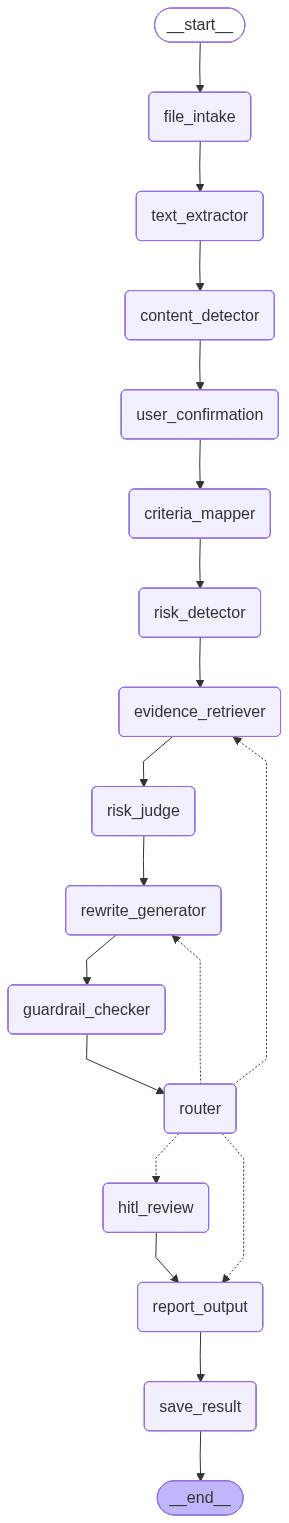

In [174]:
compliance_app

In [175]:
# ============================================================
# 실제 샘플 PDF End-to-End 실행 테스트
# ============================================================

initial_state = {
    "file_path": "data/samples/가계대출 상품설명서.pdf",
    "retry_count": 0,
    "max_retry": 2,
}

final_state = compliance_app.invoke(
    initial_state,
    config={"recursion_limit": 40},
)

print("next_action:", final_state.get("next_action"))
print("risk_level:", final_state.get("risk_level"))
print("review_required:", final_state.get("review_required"))
print("review_status:", final_state.get("review_status"))
print("guardrail_status:", final_state.get("guardrail_status"))

print("\n[saved_result]")
print(final_state.get("saved_result"))

print("\n[report]")
report = final_state.get("report", {})
print("report_id:", report.get("meta", {}).get("report_id"))
print("summary:", report.get("judgment", {}).get("summary"))
print("json_path:", final_state.get("saved_result", {}).get("json_path"))
print("csv_path:", final_state.get("saved_result", {}).get("csv_path"))

print("\n[content]")
print("file_name:", final_state.get("file_name"))
print("file_type:", final_state.get("file_type"))
print("product:", final_state.get("confirmed_product_type"))
print("channel:", final_state.get("confirmed_channel"))
print("language:", final_state.get("confirmed_language"))
print("extraction_confidence:", final_state.get("extraction_confidence"))

print("\n[counts]")
print("detected_risks:", len(final_state.get("detected_risks", [])))
print("missing_disclaimers:", len(final_state.get("missing_disclaimers", [])))
print("evidence_list:", len(final_state.get("evidence_list", [])))

next_action: done
risk_level: Medium
review_required: False
review_status: None
guardrail_status: ok

[saved_result]
{'status': 'saved', 'json_path': 'C:\\Users\\USER\\Desktop\\complypilot-jb\\outputs\\reports\\report_20260608_170034_final.json', 'csv_path': 'C:\\Users\\USER\\Desktop\\complypilot-jb\\outputs\\reports\\report_20260608_170034_final.csv', 'saved_at': '2026-06-08T17:00:34', 'error': ''}

[report]
report_id: report_20260608_170034
summary: 일부 조건 누락 가능성이 있어 수정안 확인을 권장합니다.
json_path: C:\Users\USER\Desktop\complypilot-jb\outputs\reports\report_20260608_170034_final.json
csv_path: C:\Users\USER\Desktop\complypilot-jb\outputs\reports\report_20260608_170034_final.csv

[content]
file_name: 가계대출 상품설명서.pdf
file_type: pdf
product: loan
channel: document
language: ko
extraction_confidence: 1.0

[counts]
detected_risks: 0
missing_disclaimers: 1
evidence_list: 3


In [176]:
# state 값 확인
final_state

{'file_path': 'C:\\Users\\USER\\Desktop\\complypilot-jb\\data\\samples\\가계대출 상품설명서.pdf',
 'file_name': '가계대출 상품설명서.pdf',
 'file_type': 'pdf',
 'file_size': 364508,
 'raw_text': '은행용\n\uf02a\uf031\uf031\uf031\uf030\uf039\uf030\uf030\uf035\uf030\uf02a\n준법감시인 심의필 제2018-나-195호 (심의일 : 2018. 4. 17. 현재)\n   \n가계대출 상품설명서\n1\n 상품 개요 및 상품의 특성\n \n⋅상품명 :                    \n⋅대출신청금액 :                    원\n⋅적용예정금리(보증료율) :                         %\n⋅금리적용방식 : □ 변동  □ 고정\n⋅대출기간 : 취급 후                    개월\n⋅예상 실질유효금리 :               %\n이 설명서는 은행이용자의 상품에 대한 이해를 돕고 약관의 중요내용을 알려드리기 위한 참고자료이며, 실제 \n계약은 대출거래약정서(가계용), 여신거래기본약관(가계용)이 적용됩니다. 계약을 신청하는 경우 약관이, 계약을 \n체결하는 경우 계약서류가 교부됩니다.   \n  은행은 금융소비자 보호를 위하여 대출거래의 주요내용 및 고객부담비용에 대하여 충분히 설명하여야 하며, 특\n히 취약한 금융소비자에 대해서는 금융소비자의 불이익사항을 다른 정보보다 우선적으로 설명하고 그 이해여부\n를 확인하여야 합니다.\n 「금융소비자보호 모범규준」상 강화된 설명의무 이행 대상에 해당하는지 여부를 확인하고자 하오니 아래의 항목 \n중 해당하는 유형에 체크하여 주시기 바랍니다. \n □ 만 65세 이상 □ 은퇴자 □ 주부 □ 해당사항 없음 \n[금융소비자의 불이익 사항]\n• 기한의 이익 상실 사유          • 변동금리 또는 고정금리 유의사항  